In [304]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
datos_experimentales = np.load('conversion_datos_Exp.npz')

alpha = datos_experimentales['alpha']
delta = datos_experimentales['delta']
tiempos_dias_jd = datos_experimentales['tiempos_dias_jd']



1ra Interpolación: Desde el 9 de Febrero hasta el 11 de Marzo

In [4]:
alpha_1 = alpha[0:4]
delta_1 = delta[0:4]

tiempos_uso_jd_1 = tiempos_dias_jd[0:4]  
tiempos_uso_jd_1

array([2461081.49722222, 2461100.50972222, 2461102.47638889,
       2461111.50138889])

In [5]:
tiempo_central_1 = np.mean(tiempos_uso_jd_1)
print("Tiempo central (JD):", tiempo_central_1)

Tiempo central (JD): 2461098.9961805553


In [6]:
#Construcción del vector rho

rho = np.zeros((4, 3))

for i in range(4):
    rho[i, 0] = np.cos(delta_1[i]) * np.cos(alpha_1[i])  # x
    rho[i, 1] = np.cos(delta_1[i]) * np.sin(alpha_1[i])  # y
    rho[i, 2] = np.sin(delta_1[i])                     # z

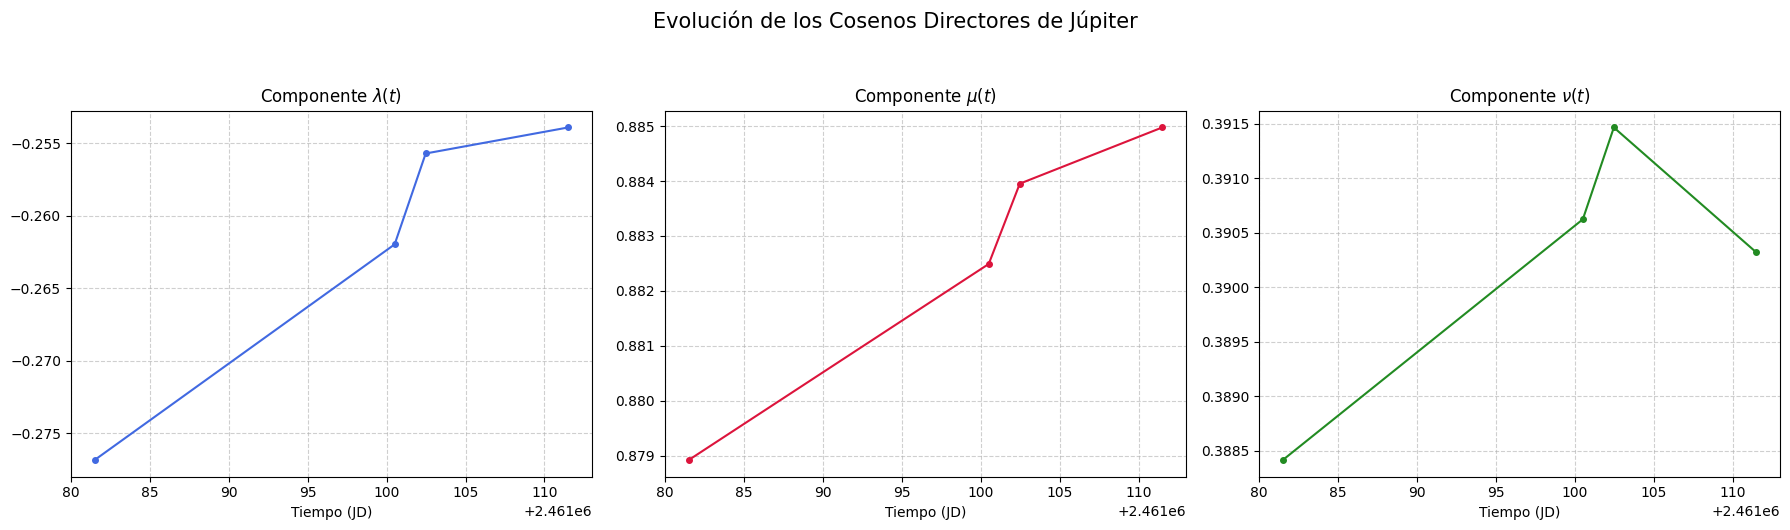

In [ ]:
"""
# 1 fila, 3 columnas. figsize ancho=18, alto=5
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

labels = [r'$\lambda(t)$', r'$\mu(t)$', r'$\nu(t)$']
colors = ['royalblue', 'crimson', 'forestgreen']

for i in range(3):
    axs[i].plot(t_1, rho[:, i], 'o-', markersize=4, color=colors[i])
    axs[i].set_title(f"Componente {labels[i]}")
    axs[i].set_xlabel("Tiempo (JD)")
    axs[i].grid(True, linestyle='--', alpha=0.6)
    
    # Esto quita el offset para que veas la variación real en el eje Y
    axs[i].yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=False))
    
    # Opcional: si los números son muy largos, rotar las etiquetas del eje Y
    # axs[i].tick_params(axis='y', rotation=45)

plt.suptitle("Evolución de los Cosenos Directores de Júpiter", fontsize=15, y=1.05)
plt.tight_layout()
plt.show()
"""

In [ ]:
"""

plt.plot(t_1, rho[:,0], 'o-', label='l(t)')
plt.plot(t_1, rho[:,1], 'o-', label='m(t)')
plt.plot(t_1, rho[:,2], 'o-', label='n(t)')

plt.xlabel("Tiempo (JD)")
plt.ylabel("Cosenos directores")
plt.title("Evolución de la dirección de observación")

plt.legend()
plt.grid()
plt.show()
"""

'"\nt_1 = tiempos_uso_jd_1  # tus tiempos originales\n\nplt.plot(t_1, rho[:,0], \'o-\', label=\'l(t)\')\nplt.plot(t_1, rho[:,1], \'o-\', label=\'m(t)\')\nplt.plot(t_1, rho[:,2], \'o-\', label=\'n(t)\')\n\nplt.xlabel("Tiempo (JD)")\nplt.ylabel("Cosenos directores")\nplt.title("Evolución de la dirección de observación")\n\nplt.legend()\nplt.grid()\nplt.show()\n'

In [7]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo = tiempos_uso_jd_1 - tiempos_uso_jd_1[0]

poly_lambda = np.polyfit(tiempo_relativo, rho[:, 0], 2)
poly_mu = np.polyfit(tiempo_relativo, rho[:, 1], 2)
poly_nu = np.polyfit(tiempo_relativo, rho[:, 2], 2)

tiempo_central_reescalado = tiempo_central_1 - tiempos_uso_jd_1[0] 

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Jessi Dani\AppData\Local\Temp\ipykernel_19052\3625810735.py:3: SyntaxWarning: invalid escape sequence '\l'
  nombres = ['Lambda ($\lambda$)', 'Mu ($\mu$)', 'Nu ($\\nu$)']
C:\Users\Jessi Dani\AppData\Local\Temp\ipykernel_19052\3625810735.py:3: SyntaxWarning: invalid escape sequence '\m'
  nombres = ['Lambda ($\lambda$)', 'Mu ($\mu$)', 'Nu ($\\nu$)']


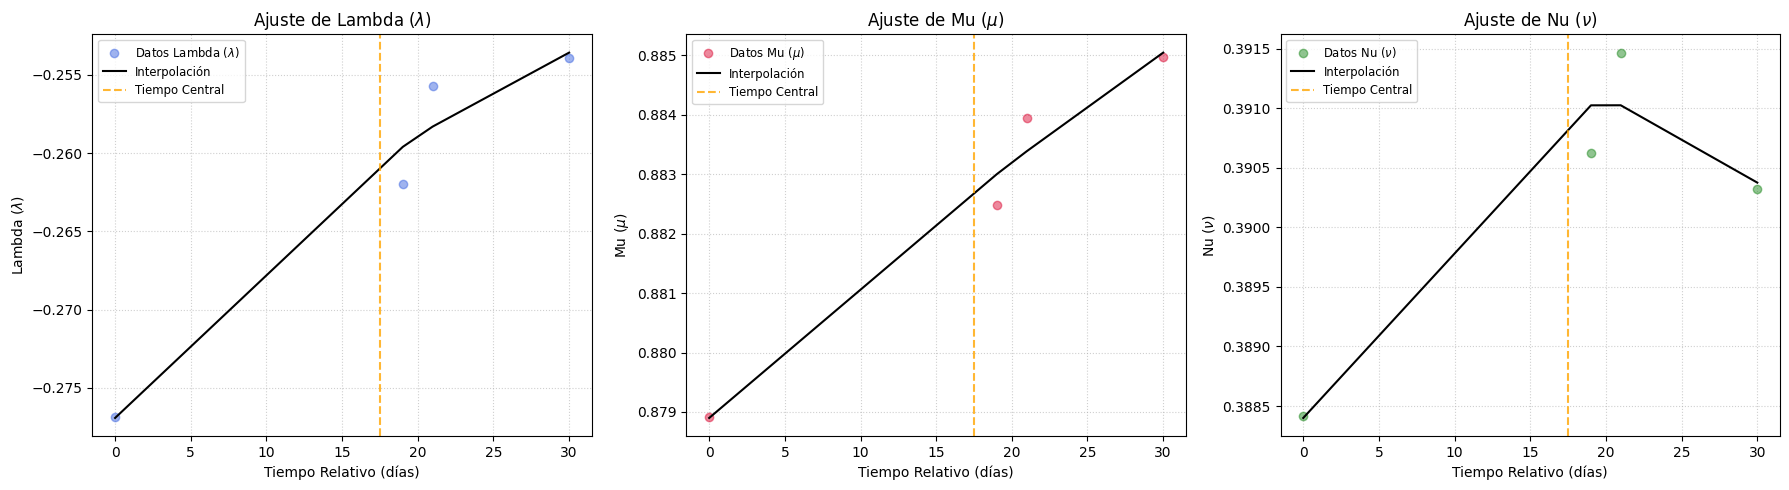

In [312]:
# Definimos las listas de datos para iterar y no repetir código
polinomios = [poly_lambda, poly_mu, poly_nu]
nombres = ['Lambda ($\lambda$)', 'Mu ($\mu$)', 'Nu ($\\nu$)']
colores = ['royalblue', 'crimson', 'forestgreen']

plt.figure(figsize=(18, 5)) # Un ancho mayor para que quepan las tres

for i in range(3):
    plt.subplot(1, 3, i + 1)
    
    # 1. Graficar los datos originales (puntos)
    plt.plot(tiempo_relativo, rho[:, i], 'o', color=colores[i], 
             alpha=0.5, label=f'Datos {nombres[i]}')
    
    # 2. Graficar la interpolación (línea continua)
    # Suponiendo que tienes poly_lambda, poly_mu y poly_nu ya definidos
    plt.plot(tiempo_relativo, np.polyval(polinomios[i], tiempo_relativo), 
             '-', color='black', linewidth=1.5, label='Interpolación')
    
    # 3. Marcar el tiempo central
    plt.axvline(tiempo_central_reescalado, color='orange', linestyle='--', 
                label='Tiempo Central', alpha=0.8)
    
    plt.xlabel('Tiempo Relativo (días)')
    plt.ylabel(nombres[i])
    plt.title(f'Ajuste de {nombres[i]}')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize='small')

    # Importante para ver las variaciones pequeñas (quita el offset)
    plt.gca().ticklabel_format(useOffset=False)
    
plt.tight_layout()
plt.show()

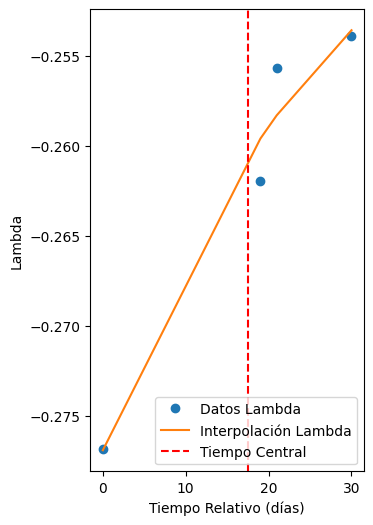

In [8]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo, rho[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo, np.polyval(poly_lambda, tiempo_relativo), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [ ]:
#Para lambda

l_val = np.polyval(poly_lambda, tiempo_central_reescalado)

derivada_1_l = np.polyder(poly_lambda,1)
l_dval = np.polyval(derivada_1_l, tiempo_central_reescalado)

derivada_2_l = np.polyder(poly_lambda,2)
l_ddval = np.polyval(derivada_2_l, tiempo_central_reescalado)

#Para mu

mu_val = np.polyval(poly_mu, tiempo_central_reescalado)

derivada_1_mu = np.polyder(poly_mu,1)
mu_dval = np.polyval(derivada_1_mu, tiempo_central_reescalado)

derivada_2_mu = np.polyder(poly_mu,2)
mu_ddval = np.polyval(derivada_2_mu, tiempo_central_reescalado)

#Para nu

nu_val = np.polyval(poly_nu, tiempo_central_reescalado)

derivada_1_nu = np.polyder(poly_nu,1)
nu_dval = np.polyval(derivada_1_nu, tiempo_central_reescalado)

derivada_2_nu = np.polyder(poly_nu,2)
nu_ddval = np.polyval(derivada_2_nu, tiempo_central_reescalado)

In [ ]:
"""
poly_lambda = np.polyfit(tiempo_relativo, rho[:, 0], 2)
poly_mu     = np.polyfit(tiempo_relativo, rho[:, 1], 2)
poly_nu     = np.polyfit(tiempo_relativo, rho[:, 2], 2)
"""

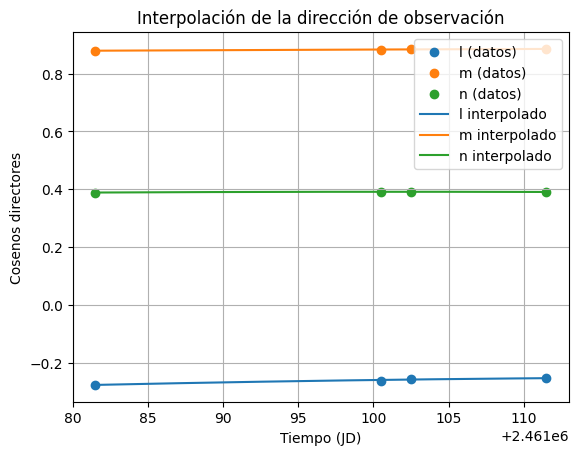

In [ ]:
"""
t_suave = np.linspace(tiempo_relativo[0], tiempo_relativo[-1], 200)

l_suave = np.polyval(poly_lambda, t_suave)
m_suave = np.polyval(poly_mu, t_suave)
n_suave = np.polyval(poly_nu, t_suave)

t_real = t_suave + tiempos_uso_jd_1[0]

# puntos originales
plt.scatter(tiempos_uso_jd_1, rho[:,0], label='l (datos)')
plt.scatter(tiempos_uso_jd_1, rho[:,1], label='m (datos)')
plt.scatter(tiempos_uso_jd_1, rho[:,2], label='n (datos)')

# curvas suaves
plt.plot(t_real, l_suave, '-', label='l interpolado')
plt.plot(t_real, m_suave, '-', label='m interpolado')
plt.plot(t_real, n_suave, '-', label='n interpolado')

plt.xlabel("Tiempo (JD)")
plt.ylabel("Cosenos directores")
plt.title("Interpolación de la dirección de observación")

plt.legend()
plt.grid()
plt.show()
"""

In [10]:
#l_val, mu_val y nu_val están dentro del rango de -1 a 1.
#l_dval está en el rango de 10e-3, y mu_dval y nu_dval están en el rango de 10e-4.
#l_ddval, mu_ddval y nu_ddval están en el rango de 10e-5. Esto es consistente con lo que se espera para las posiciones y velocidades de un planeta en el sistema solar.

In [11]:
#Datos de las efemérides del Sol

X = -0.92166819869956
Y = 0.3624168676580381
Z = -1.877615350367358e-5


#Distancia desde el Sol hasta el planeta Tierra (aproximadamente 1UA)
R = np.sqrt(X**2 + Y**2 + Z**2)

In [12]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D = np.array([
    [l_val,  l_dval,  l_ddval],
    [mu_val, mu_dval, mu_ddval],
    [nu_val, nu_dval, nu_ddval]
])

# Calcular el determinante D
D = np.linalg.det(matriz_D)
print("Determinante D:", D)

#D está dando 4.5923456027e-08. O los datos están muys eguidos entre sí, o estamos haciendo algo mal. Revisar.

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1 = np.array([
    [l_val, l_dval, X],
    [mu_val, mu_dval, Y],
    [nu_val, nu_dval, Z]
])

#Calcular el determiante D1
D1 = k2* np.linalg.det(matriz_D1)
print("Determinante D1:", D1)

Determinante D: 9.617489848395426e-09
Determinante D1: 4.438547931492719e-08


In [13]:
#Intento preliminar
intento = D1/D * (1/(0.99)**3 - 1/(5.2)**3)
intento

np.float64(4.72352537608512)

In [14]:
cos_phi = (l_val*X + mu_val*Y +nu_val*Z)/(R)

# Bucle para hallar r y rho

r_obj = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new = (D1 / D) * (1/R**3 - 1/r_obj**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj = np.sqrt(rho_new**2 + R**2 + 2 * rho_new * R * cos_phi)
    
    print(f"{i:<5} | {rho_new:<15.8f} | {r_obj:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new - rho_old) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old = rho_new
    i += 1

rho_final = rho_new
r_final = r_obj

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 4.71830171      | 5.34125438     
1     | 4.72083750      | 5.34376036     
2     | 4.72088009      | 5.34380245     
3     | 4.72088080      | 5.34380316     
4     | 4.72088082      | 5.34380317     
5     | 4.72088082      | 5.34380317     
----------------------------------------
¡Convergencia lograda en 5 iteraciones!

Distancia Tierra-Júpiter (rho): 4.720881 UA
Distancia Sol-Júpiter (r): 5.343803 UA


In [15]:
#Finalmente, el vectoor de jupiter es

x_jup = X + rho_final * l_val
y_jup = Y + rho_final * mu_val
z_jup = Z + rho_final * nu_val

vector_r_jupiter = np.array([x_jup, y_jup, z_jup])
vector_r_jupiter

array([-2.15220284,  4.52954961,  1.8457969 ])

In [16]:
np.linalg.norm(vector_r_jupiter)

np.float64(5.343759250501187)

2da Interpolación: Desde el 28 de Febrero hasta el 19 de Marzo

In [17]:
tiempos_uso_jd_2 = tiempos_dias_jd[1:5]  
tiempos_uso_jd_2

array([2461100.50972222, 2461102.47638889, 2461111.50138889,
       2461119.54305556])

In [18]:
tiempo_central_2 = np.mean(tiempos_uso_jd_2)
tiempo_central_2

np.float64(2461108.507638889)

In [19]:
#Construcción del vector rho

alpha_2 = alpha[1:5]
delta_2 = delta[1:5]

rho_2 = np.zeros((4, 3))

for i in range(4):
    rho_2[i, 0] = np.cos(delta_2[i]) * np.cos(alpha_2[i])  # x
    rho_2[i, 1] = np.cos(delta_2[i]) * np.sin(alpha_2[i])  # y
    rho_2[i, 2] = np.sin(delta_2[i])                     # z

In [20]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c: Revisar

tiempo_relativo_2 = tiempos_uso_jd_2 - tiempos_uso_jd_2[0]

poly_lambda_2 = np.polyfit(tiempo_relativo_2, rho_2[:, 0], 2)
poly_mu_2 = np.polyfit(tiempo_relativo_2, rho_2[:, 1], 2)
poly_nu_2 = np.polyfit(tiempo_relativo_2, rho_2[:, 2], 2)

tiempo_central_reescalado_2 = tiempo_central_2 - tiempos_uso_jd_2[0] 

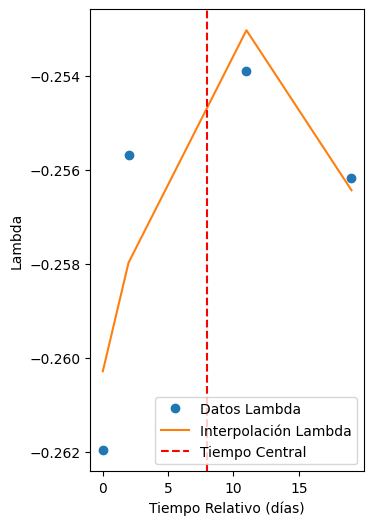

In [21]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_2, rho_2[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_2, np.polyval(poly_lambda_2, tiempo_relativo_2), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_2, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [22]:
#Para lambda

l_val_2 = np.polyval(poly_lambda_2, tiempo_central_reescalado_2)

derivada_1_l_2 = np.polyder(poly_lambda_2,1)
l_dval_2 = np.polyval(derivada_1_l_2, tiempo_central_reescalado_2)

derivada_2_l_2 = np.polyder(poly_lambda_2,2)
l_ddval_2 = np.polyval(derivada_2_l_2, tiempo_central_reescalado_2)

#Para mu

mu_val_2 = np.polyval(poly_mu_2, tiempo_central_reescalado_2)

derivada_1_mu_2 = np.polyder(poly_mu_2,1)
mu_dval_2 = np.polyval(derivada_1_mu_2, tiempo_central_reescalado_2)

derivada_2_mu_2 = np.polyder(poly_mu_2,2)
mu_ddval_2 = np.polyval(derivada_2_mu_2, tiempo_central_reescalado_2)

#Para nu

nu_val_2 = np.polyval(poly_nu_2, tiempo_central_reescalado_2)

derivada_1_nu_2 = np.polyder(poly_nu_2,1)
nu_dval_2 = np.polyval(derivada_1_nu_2, tiempo_central_reescalado_2)

derivada_2_nu_2 = np.polyder(poly_nu_2,2)
nu_ddval_2 = np.polyval(derivada_2_nu_2, tiempo_central_reescalado_2)

In [23]:
X_2 = -0.9712751310029790
Y_2 = 0.2052987725362495
Z_2 = -4.038939877607600e-06

R_2 = np.sqrt(X_2**2 + Y_2**2 + Z_2**2)
R_2


np.float64(0.992735093630752)

In [24]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_2 = np.array([
    [l_val_2,  l_dval_2,  l_ddval_2],
    [mu_val_2, mu_dval_2, mu_ddval_2],
    [nu_val_2, nu_dval_2, nu_ddval_2]
])

# Calcular el determinante D
D_2 = np.linalg.det(matriz_D_2)
print(D_2)

#D está dando 6.040795640314e-08. O los datos están muys eguidos entre sí, o estamos haciendo algo mal. Revisar.

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_2 = np.array([
    [l_val_2, l_dval_2, X_2],
    [mu_val_2, mu_dval_2, Y_2],
    [nu_val_2, nu_dval_2, Z_2]
])

#Calcular el determiante D1
D1_2 = -k2* np.linalg.det(matriz_D1_2)
print(D1_2)

-3.6824741437939543e-09
-2.5358369446372463e-08


In [25]:
#Intento preliminar
intento_2 = D1_2/(D_2) * (1/(0.99)**3 - 1/(5.2)**3)
intento_2

np.float64(7.048045415823608)

In [26]:
cos_phi_2 = (l_val_2*X_2 + mu_val_2*Y_2 +nu_val_2*Z_2)/(R_2)

# Bucle para hallar r y rho

r_obj_2 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_2 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_2 = (D1_2 / D_2) * (1/R_2**3 - 1/r_obj_2**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_2 = np.sqrt(rho_new_2**2 + R_2**2 + 2 * rho_new_2 * R_2 * cos_phi_2)
    
    print(f"{i:<5} | {rho_new_2:<15.8f} | {r_obj_2:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_2 - rho_old_2) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_2 = rho_new_2
    i += 1

rho_final_2 = rho_new_2
r_final_2 = r_obj_2

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_2:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_2:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 6.98954768      | 7.47147458     
1     | 7.02201177      | 7.50370554     
2     | 7.02222361      | 7.50391587     
3     | 7.02222498      | 7.50391723     
4     | 7.02222499      | 7.50391724     
----------------------------------------
¡Convergencia lograda en 4 iteraciones!

Distancia Tierra-Júpiter (rho): 7.022225 UA
Distancia Sol-Júpiter (r): 7.503917 UA


In [27]:
#Finalmente, el vectoor de jupiter es

x_jup_2 = X_2 + rho_final_2 * l_val_2
y_jup_2 = Y_2 + rho_final_2 * mu_val_2
z_jup_2 = Z_2 + rho_final_2 * nu_val_2

vector_r_jupiter_2 = np.array([x_jup_2, y_jup_2, z_jup_2])
vector_r_jupiter_2

array([-2.75245225,  6.4196643 ,  2.74242278])

In [28]:
np.linalg.norm(vector_r_jupiter_2)

np.float64(7.503930021975989)

3ra Interpolación: desde el 9 de Febrero hasta el 11 de Marzo


In [29]:
tiempos_uso_jd_3 = [tiempos_dias_jd[0],tiempos_dias_jd[1],tiempos_dias_jd[3],tiempos_dias_jd[5]]  
print(tiempos_uso_jd_3)

tiempo_central_3 = np.mean(tiempos_uso_jd_3)
print(tiempo_central_3)

#Construcción del vector rho

alpha_3 = [alpha[0],alpha[1],alpha[3],alpha[5]]
delta_3 = [delta[0],delta[1],delta[3],delta[5]]

rho_3 = np.zeros((4, 3))

for i in range(4):
    rho_3[i, 0] = np.cos(delta_3[i]) * np.cos(alpha_3[i])  # x
    rho_3[i, 1] = np.cos(delta_3[i]) * np.sin(alpha_3[i])  # y
    rho_3[i, 2] = np.sin(delta_3[i])                     # z


[np.float64(2461081.4972222224), np.float64(2461100.509722222), np.float64(2461111.501388889), np.float64(2461126.504166667)]
2461105.003125


In [30]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_3 = tiempos_uso_jd_3 - tiempos_uso_jd_3[0]

poly_lambda_3 = np.polyfit(tiempo_relativo_3, rho_3[:, 0], 2)
poly_mu_3 = np.polyfit(tiempo_relativo_3, rho_3[:, 1], 2)
poly_nu_3 = np.polyfit(tiempo_relativo_3, rho_3[:, 2], 2)

tiempo_central_reescalado_3 = tiempo_central_3 - tiempos_uso_jd_3[0] 

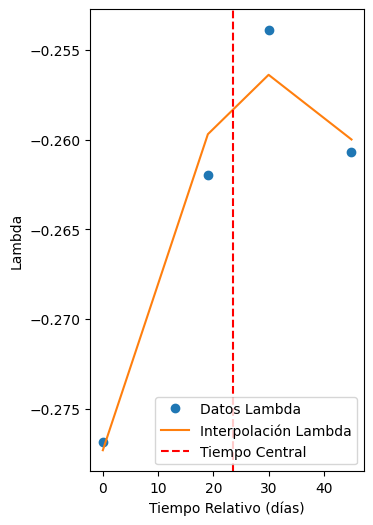

In [31]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_3, rho_3[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_3, np.polyval(poly_lambda_3, tiempo_relativo_3), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_3, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [32]:
#Para lambda

l_val_3 = np.polyval(poly_lambda_3, tiempo_central_reescalado_3)

derivada_1_l_3 = np.polyder(poly_lambda_3,1)
l_dval_3 = np.polyval(derivada_1_l_3, tiempo_central_reescalado_3)

derivada_2_l_3 = np.polyder(poly_lambda_3,2)
l_ddval_3 = np.polyval(derivada_2_l_3, tiempo_central_reescalado_3)

#Para mu

mu_val_3 = np.polyval(poly_mu_3, tiempo_central_reescalado_3)

derivada_1_mu_3 = np.polyder(poly_mu_3,1)
mu_dval_3 = np.polyval(derivada_1_mu_3, tiempo_central_reescalado_3)

derivada_2_mu_3 = np.polyder(poly_mu_3,2)
mu_ddval_3 = np.polyval(derivada_2_mu_3, tiempo_central_reescalado_3)

#Para nu

nu_val_3 = np.polyval(poly_nu_3, tiempo_central_reescalado_3)

derivada_1_nu_3 = np.polyder(poly_nu_3,1)
nu_dval_3 = np.polyval(derivada_1_nu_3, tiempo_central_reescalado_3)

derivada_2_nu_3 = np.polyder(poly_nu_3,2)
nu_ddval_3 = np.polyval(derivada_2_nu_3, tiempo_central_reescalado_3)

In [33]:
X_3= -9.560206927483522e-01
Y_3 = 2.640757619855256e-01
Z_3 = -9.056560159715226e-06

R_3 = np.sqrt(X_3**2 + Y_3**2 + Z_3**2)
print(R_3)

0.9918223495733984


In [34]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_3 = np.array([
    [l_val_3,  l_dval_3,  l_ddval_3],
    [mu_val_3, mu_dval_3, mu_ddval_3],
    [nu_val_3, nu_dval_3, nu_ddval_3]
])

# Calcular el determinante D
D_3 = np.linalg.det(matriz_D_3)
print(D_3)

#D está dando 6.040795640314e-08. O los datos están muys eguidos entre sí, o estamos haciendo algo mal. Revisar.

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_3 = np.array([
    [l_val_3, l_dval_3, X_3],
    [mu_val_3, mu_dval_3, Y_3],
    [nu_val_3, nu_dval_3, Z_3]
])

#Calcular el determiante D1
D1_3 = -k2* np.linalg.det(matriz_D1_3)
print(D1_3)

-2.2967235108865333e-09
-4.470321426920241e-09


In [35]:
#Intento preliminar
intento_3 = D1_3/D_3 * (1/(0.99)**3 - 1/(5.2)**3)
intento_3

np.float64(1.9921274060236818)

In [36]:
cos_phi_3 = (l_val_3*X_3 + mu_val_3*Y_3 +nu_val_3*Z_3)/(R_3)

# Bucle para hallar r y rho

r_obj_3 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_3 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_3 = (D1_3 / D_3) * (1/R_3**3 - 1/r_obj_3**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_3 = np.sqrt(rho_new_3**2 + R_3**2 + 2 * rho_new_3 * R_3 * cos_phi_3)
    
    print(f"{i:<5} | {rho_new_3:<15.8f} | {r_obj_3:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_3 - rho_old_3) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_3 = rho_new_3
    i += 1

rho_final_3 = rho_new_3
r_final_3 = r_obj_3

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_3:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_3:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 1.98109055      | 2.60949059     
1     | 1.88539573      | 2.51944673     
2     | 1.87322652      | 2.50802613     
3     | 1.87155632      | 2.50645923     
4     | 1.87132479      | 2.50624203     
5     | 1.87129265      | 2.50621188     
6     | 1.87128819      | 2.50620769     
7     | 1.87128757      | 2.50620711     
8     | 1.87128749      | 2.50620703     
9     | 1.87128747      | 2.50620702     
10    | 1.87128747      | 2.50620702     
----------------------------------------
¡Convergencia lograda en 10 iteraciones!

Distancia Tierra-Júpiter (rho): 1.871287 UA
Distancia Sol-Júpiter (r): 2.506207 UA


In [37]:
#Finalmente, el vector de jupiter es

x_jup_3 = X_3 + rho_final_3 * l_val_3
y_jup_3 = Y_3 + rho_final_3 * mu_val_3
z_jup_3 = Z_3 + rho_final_3 * nu_val_3

vector_r_jupiter_3 = np.array([x_jup_3, y_jup_3, z_jup_3])
vector_r_jupiter_3

array([-1.43832142,  1.91791841,  0.73065112])

In [38]:
np.linalg.norm(vector_r_jupiter_3)

np.float64(2.506198437546626)

4ta Interpolación: Desde el 9 de Febrero hasta el 11 de marzo


In [39]:
tiempos_uso_jd_4 = [tiempos_dias_jd[0],tiempos_dias_jd[1],tiempos_dias_jd[3]]  
print(tiempos_uso_jd_4)

tiempo_central_4 = np.mean(tiempos_uso_jd_4)
print(tiempo_central_4)

#Construcción del vector rho

alpha_4 = [alpha[0],alpha[1],alpha[3]]
delta_4 = [delta[0],delta[1],delta[3]]

rho_4 = np.zeros((3, 3))

for i in range(3):
    rho_4[i, 0] = np.cos(delta_4[i]) * np.cos(alpha_4[i])  # x
    rho_4[i, 1] = np.cos(delta_4[i]) * np.sin(alpha_4[i])  # y
    rho_4[i, 2] = np.sin(delta_4[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461100.509722222), np.float64(2461111.501388889)]
2461097.836111111


In [40]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_4 = tiempos_uso_jd_4 - tiempos_uso_jd_4[0]

poly_lambda_4 = np.polyfit(tiempo_relativo_4, rho_4[:, 0], 2)
poly_mu_4 = np.polyfit(tiempo_relativo_4, rho_4[:, 1], 2)
poly_nu_4 = np.polyfit(tiempo_relativo_4, rho_4[:, 2], 2)

tiempo_central_reescalado_4 = tiempo_central_4 - tiempos_uso_jd_4[0] 

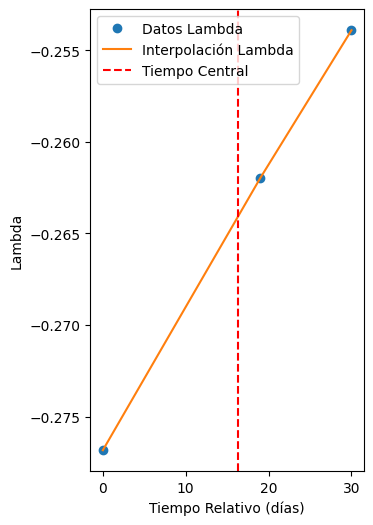

In [41]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_4, rho_4[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_4, np.polyval(poly_lambda_4, tiempo_relativo_4), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_4, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [42]:
#Para lambda

l_val_4 = np.polyval(poly_lambda_4, tiempo_central_reescalado_4)

derivada_1_l_4 = np.polyder(poly_lambda_4,1)
l_dval_4 = np.polyval(derivada_1_l_4, tiempo_central_reescalado_4)

derivada_2_l_4 = np.polyder(poly_lambda_4,2)
l_ddval_4 = np.polyval(derivada_2_l_4, tiempo_central_reescalado_4)

#Para mu

mu_val_4 = np.polyval(poly_mu_4, tiempo_central_reescalado_4)

derivada_1_mu_4 = np.polyder(poly_mu_4,1)
mu_dval_4 = np.polyval(derivada_1_mu_4, tiempo_central_reescalado_4)

derivada_2_mu_4 = np.polyder(poly_mu_4,2)
mu_ddval_4 = np.polyval(derivada_2_mu_4, tiempo_central_reescalado_4)

#Para nu

nu_val_4 = np.polyval(poly_nu_4, tiempo_central_reescalado_4)

derivada_1_nu_4 = np.polyder(poly_nu_4,1)
nu_dval_4 = np.polyval(derivada_1_nu_4, tiempo_central_reescalado_4)

derivada_2_nu_4 = np.polyder(poly_nu_4,2)
nu_ddval_4 = np.polyval(derivada_2_nu_4, tiempo_central_reescalado_4)

In [43]:
X_4= -9.138598924862512e-01
Y_4 = 3.809885458856218e-01
Z_4 = -2.032949553775871e-05

R_4 = np.sqrt(X_4**2 + Y_4**2 + Z_4**2)
print(R_4)

0.9900970536287398


In [44]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_4 = np.array([
    [l_val_4,  l_dval_4,  l_ddval_4],
    [mu_val_4, mu_dval_4, mu_ddval_4],
    [nu_val_4, nu_dval_4, nu_ddval_4]
])

# Calcular el determinante D
D_4 = np.linalg.det(matriz_D_4)
print(D_4)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_4 = np.array([
    [l_val_4, l_dval_4, X_4],
    [mu_val_4, mu_dval_4, Y_4],
    [nu_val_4, nu_dval_4, Z_4]
])

#Calcular el determiante D1
D1_4 = k2* np.linalg.det(matriz_D1_4)
print(D1_4)

7.857353753665259e-09
4.4571755886877895e-08


In [45]:
#Intento preliminar
intento_4 = D1_4/D_4 * (1/(0.99)**3 - 1/(5.2)**3)
intento_4

np.float64(5.8059128449523305)

In [46]:
cos_phi_4 = (l_val_4*X_4 + mu_val_4*Y_4 +nu_val_4*Z_4)/(R_4)

# Bucle para hallar r y rho

r_obj_4 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_4 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_4 = (D1_4 / D_4) * (1/R_4**3 - 1/r_obj_4**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_4 = np.sqrt(rho_new_4**2 + R_4**2 + 2 * rho_new_4 * R_4 * cos_phi_4)
    
    print(f"{i:<5} | {rho_new_4:<15.8f} | {r_obj_4:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_4 - rho_old_4) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_4 = rho_new_4
    i += 1

rho_final_4 = rho_new_4
r_final_4 = r_obj_4

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_4:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_4:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 5.80419379      | 6.43193699     
1     | 5.82321870      | 6.45081297     
2     | 5.82340530      | 6.45099811     
3     | 5.82340712      | 6.45099992     
4     | 5.82340713      | 6.45099993     
5     | 5.82340713      | 6.45099993     
----------------------------------------
¡Convergencia lograda en 5 iteraciones!

Distancia Tierra-Júpiter (rho): 5.823407 UA
Distancia Sol-Júpiter (r): 6.451000 UA


In [47]:
#Finalmente, el vectoor de jupiter es

x_jup_4 = X_4 + rho_final_4 * l_val_4
y_jup_4 = Y_4 + rho_final_4 * mu_val_4
z_jup_4 = Z_4 + rho_final_4 * nu_val_4

vector_r_jupiter_4 = np.array([x_jup_4, y_jup_4, z_jup_4])
vector_r_jupiter_4

array([-2.45114894,  5.51683348,  2.27415212])

In [48]:
np.linalg.norm(vector_r_jupiter_4)

np.float64(6.450996097343615)

5ta Interpolación: 9 de febrero, 2 de marzo y 26 de marzo

In [49]:
tiempos_uso_jd_5 = [tiempos_dias_jd[0],tiempos_dias_jd[2],tiempos_dias_jd[5]]  
print(tiempos_uso_jd_5)

tiempo_central_5 = np.mean(tiempos_uso_jd_5)
print(tiempo_central_5)

#Construcción del vector rho

alpha_5 = [alpha[0],alpha[2],alpha[5]]
delta_5 = [delta[0],delta[2],delta[5]]

rho_5 = np.zeros((3, 3))

for i in range(3):
    rho_5[i, 0] = np.cos(delta_5[i]) * np.cos(alpha_5[i])  # x
    rho_5[i, 1] = np.cos(delta_5[i]) * np.sin(alpha_5[i])  # y
    rho_5[i, 2] = np.sin(delta_5[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461102.476388889), np.float64(2461126.504166667)]
2461103.4925925923


In [50]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_5 = tiempos_uso_jd_5 - tiempos_uso_jd_5[0]

poly_lambda_5 = np.polyfit(tiempo_relativo_5, rho_5[:, 0], 2)
poly_mu_5 = np.polyfit(tiempo_relativo_5, rho_5[:, 1], 2)
poly_nu_5 = np.polyfit(tiempo_relativo_5, rho_5[:, 2], 2)

tiempo_central_reescalado_5 = tiempo_central_5 - tiempos_uso_jd_5[0] 

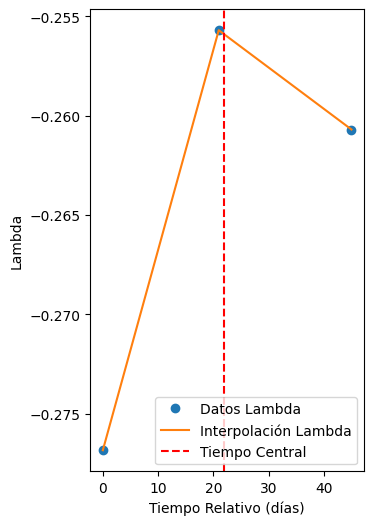

In [51]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_5, rho_5[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_5, np.polyval(poly_lambda_5, tiempo_relativo_5), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_5, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [52]:
#Para lambda

l_val_5 = np.polyval(poly_lambda_5, tiempo_central_reescalado_5)

derivada_1_l_5 = np.polyder(poly_lambda_5,1)
l_dval_5 = np.polyval(derivada_1_l_5, tiempo_central_reescalado_5)

derivada_2_l_5 = np.polyder(poly_lambda_5,2)
l_ddval_5 = np.polyval(derivada_2_l_5, tiempo_central_reescalado_5)

#Para mu

mu_val_5 = np.polyval(poly_mu_5, tiempo_central_reescalado_5)

derivada_1_mu_5 = np.polyder(poly_mu_5,1)
mu_dval_5 = np.polyval(derivada_1_mu_5, tiempo_central_reescalado_5)

derivada_2_mu_5 = np.polyder(poly_mu_5,2)
mu_ddval_5 = np.polyval(derivada_2_mu_5, tiempo_central_reescalado_5)

#Para nu

nu_val_5 = np.polyval(poly_nu_5, tiempo_central_reescalado_5)

derivada_1_nu_5 = np.polyder(poly_nu_5,1)
nu_dval_5 = np.polyval(derivada_1_nu_5, tiempo_central_reescalado_5)

derivada_2_nu_5 = np.polyder(poly_nu_5,2)
nu_ddval_5 = np.polyval(derivada_2_nu_5, tiempo_central_reescalado_5)

In [53]:
X_5= -9.483500860814637e-01
Y_5 = 2.891179792106734e-01
Z_5 = -1.154148494709073e-05

R_5 = np.sqrt(X_5**2 + Y_5**2 + Z_5**2)
print(R_5)

0.9914419255845441


In [54]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_5 = np.array([
    [l_val_5,  l_dval_5,  l_ddval_5],
    [mu_val_5, mu_dval_5, mu_ddval_5],
    [nu_val_5, nu_dval_5, nu_ddval_5]
])

# Calcular el determinante D
D_5 = np.linalg.det(matriz_D_5)
print(D_5)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_5 = np.array([
    [l_val_5, l_dval_5, X_5],
    [mu_val_5, mu_dval_5, Y_5],
    [nu_val_5, nu_dval_5, Z_5]
])

#Calcular el determiante D1
D1_5 = -k2* np.linalg.det(matriz_D1_5)
print(D1_5)

-1.6856680995199179e-09
-5.7689016152615695e-09


In [55]:
#Intento preliminar
intento_5 = D1_5/D_5 * (1/(0.99)**3 - 1/(5.2)**3)
intento_5

np.float64(3.502741917441466)

In [56]:
cos_phi_5 = (l_val_5*X_5 + mu_val_5*Y_5 +nu_val_5*Z_5)/(R_5)

# Bucle para hallar r y rho

r_obj_5 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_5 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_5 = (D1_5 / D_5) * (1/R_5**3 - 1/r_obj_5**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_5 = np.sqrt(rho_new_5**2 + R_5**2 + 2 * rho_new_5 * R_5 * cos_phi_5)
    
    print(f"{i:<5} | {rho_new_5:<15.8f} | {r_obj_5:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_5 - rho_old_5) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_5 = rho_new_5
    i += 1

rho_final_5 = rho_new_5
r_final_5 = r_obj_5

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_5:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_5:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 3.48737522      | 4.07626580     
1     | 3.46118651      | 4.05066683     
2     | 3.46022248      | 4.04972465     
3     | 3.46018653      | 4.04968952     
4     | 3.46018519      | 4.04968820     
5     | 3.46018514      | 4.04968816     
6     | 3.46018514      | 4.04968815     
----------------------------------------
¡Convergencia lograda en 6 iteraciones!

Distancia Tierra-Júpiter (rho): 3.460185 UA
Distancia Sol-Júpiter (r): 4.049688 UA


In [57]:
#Finalmente, el vectoor de jupiter es

x_jup_5 = X_5 + rho_final_5 * l_val_5
y_jup_5 = Y_5 + rho_final_5 * mu_val_5
z_jup_5 = Z_5 + rho_final_5 * nu_val_5

vector_r_jupiter_5 = np.array([x_jup_5, y_jup_5, z_jup_5])
vector_r_jupiter_5

array([-1.83165476,  3.348082  ,  1.35480636])

In [58]:
np.linalg.norm(vector_r_jupiter_5)

np.float64(4.049705240572974)

6ta interpolación:09/02; 02/03;11/03;26/03


In [59]:
tiempos_uso_jd_6 = [tiempos_dias_jd[0],tiempos_dias_jd[2],tiempos_dias_jd[3],tiempos_dias_jd[5]]  
print(tiempos_uso_jd_6)

tiempo_central_6 = np.mean(tiempos_uso_jd_6)
print(tiempo_central_6)

#Construcción del vector rho

alpha_6 = [alpha[0],alpha[2],alpha[3],alpha[5]]
delta_6 = [delta[0],delta[2],delta[3],delta[5]]

rho_6 = np.zeros((4, 3))

for i in range(4):
    rho_6[i, 0] = np.cos(delta_6[i]) * np.cos(alpha_6[i])  # x
    rho_6[i, 1] = np.cos(delta_6[i]) * np.sin(alpha_6[i])  # y
    rho_6[i, 2] = np.sin(delta_6[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461102.476388889), np.float64(2461111.501388889), np.float64(2461126.504166667)]
2461105.4947916665


In [60]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_6 = tiempos_uso_jd_6 - tiempos_uso_jd_6[0]

poly_lambda_6 = np.polyfit(tiempo_relativo_6, rho_6[:, 0], 2)
poly_mu_6 = np.polyfit(tiempo_relativo_6, rho_6[:, 1], 2)
poly_nu_6 = np.polyfit(tiempo_relativo_6, rho_6[:, 2], 2)

tiempo_central_reescalado_6 = tiempo_central_6 - tiempos_uso_jd_6[0] 

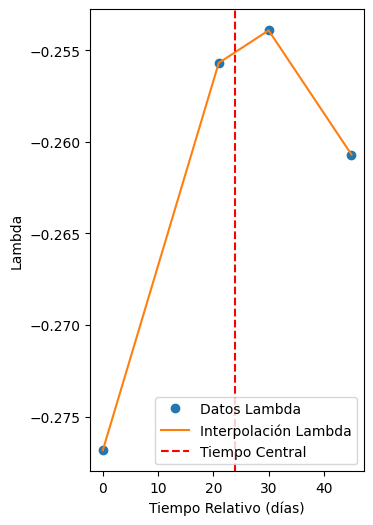

In [61]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_6, rho_6[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_6, np.polyval(poly_lambda_6, tiempo_relativo_6), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_6, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [62]:
#Para lambda

l_val_6 = np.polyval(poly_lambda_6, tiempo_central_reescalado_6)

derivada_1_l_6 = np.polyder(poly_lambda_6,1)
l_dval_6 = np.polyval(derivada_1_l_6, tiempo_central_reescalado_6)

derivada_2_l_6 = np.polyder(poly_lambda_6,2)
l_ddval_6 = np.polyval(derivada_2_l_6, tiempo_central_reescalado_6)

#Para mu

mu_val_6 = np.polyval(poly_mu_6, tiempo_central_reescalado_6)

derivada_1_mu_6 = np.polyder(poly_mu_6,1)
mu_dval_6 = np.polyval(derivada_1_mu_6, tiempo_central_reescalado_6)

derivada_2_mu_6 = np.polyder(poly_mu_6,2)
mu_ddval_6 = np.polyval(derivada_2_mu_6, tiempo_central_reescalado_6)

#Para nu

nu_val_6 = np.polyval(poly_nu_6, tiempo_central_reescalado_6)

derivada_1_nu_6 = np.polyder(poly_nu_6,1)
nu_dval_6 = np.polyval(derivada_1_nu_6, tiempo_central_reescalado_6)

derivada_2_nu_6 = np.polyder(poly_nu_6,2)
nu_ddval_6 = np.polyval(derivada_2_nu_6, tiempo_central_reescalado_6)

In [63]:
X_6= -9.583757011429926e-01
Y_6 = 2.558843792972298e-01
Z_6 = -8.277960093075756e-06

R_6 = np.sqrt(X_6**2 + Y_6**2 + Z_6**2)
print(R_6)

0.9919479825969585


In [64]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_6 = np.array([
    [l_val_6,  l_dval_6,  l_ddval_6],
    [mu_val_6, mu_dval_6, mu_ddval_6],
    [nu_val_6, nu_dval_6, nu_ddval_6]
])

# Calcular el determinante D
D_6 = np.linalg.det(matriz_D_6)
print(D_6)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_6 = np.array([
    [l_val_6, l_dval_6, X_6],
    [mu_val_6, mu_dval_6, Y_6],
    [nu_val_6, nu_dval_6, Z_6]
])

#Calcular el determiante D1
D1_6 = -k2* np.linalg.det(matriz_D1_6)
print(D1_6)

-2.400294398003716e-09
-1.5687381740347877e-09


In [65]:
#Intento preliminar
intento_6 = D1_6/D_6 * (1/(0.99)**3 - 1/(5.2)**3)
intento_6

np.float64(0.6689182249192084)

In [66]:
cos_phi_6 = (l_val_6*X_6 + mu_val_6*Y_6 +nu_val_6*Z_6)/(R_6)

# Bucle para hallar r y rho

r_obj_6 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_6 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_6 = (D1_6 / D_6) * (1/R_6**3 - 1/r_obj_6**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_6 = np.sqrt(rho_new_6**2 + R_6**2 + 2 * rho_new_6 * R_6 * cos_phi_6)
    
    print(f"{i:<5} | {rho_new_6:<15.8f} | {r_obj_6:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_6 - rho_old_6) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_6 = rho_new_6
    i += 1

rho_final_6 = rho_new_6
r_final_6 = r_obj_6

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_6:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_6:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 0.66495777      | 1.43235501     
1     | 0.44720631      | 1.26674050     
2     | 0.34807478      | 1.19688896     
3     | 0.28843091      | 1.15692430     
4     | 0.24754887      | 1.13053308     
5     | 0.21729594      | 1.11156820     
6     | 0.19374762      | 1.09715682     
7     | 0.17474875      | 1.08576252     
8     | 0.15900517      | 1.07648322     
9     | 0.14568687      | 1.06875157     
10    | 0.13423388      | 1.06219132     
11    | 0.12425288      | 1.05654226     
12    | 0.11545843      | 1.05161812     
13    | 0.10763764      | 1.04728174     
14    | 0.10062803      | 1.04342963     
15    | 0.09430311      | 1.03998209     
16    | 0.08856275      | 1.03687666     
17    | 0.08332644      | 1.03406357     
18    | 0.07852863      | 1.03150265     
19    | 0.07411528      | 1.02916106     
20    | 0.07004138      | 1.02701168     
21    | 0.06626909      | 1.0250318

In [67]:
#Finalmente, el vectoor de jupiter es

x_jup_6 = X_6 + rho_final_6 * l_val_6
y_jup_6 = Y_6 + rho_final_6 * mu_val_6
z_jup_6 = Z_6 + rho_final_6 * nu_val_6

vector_r_jupiter_6 = np.array([x_jup_6, y_jup_6, z_jup_6])
vector_r_jupiter_6

array([-0.96287314,  0.27150894,  0.00689661])

In [68]:
np.linalg.norm(vector_r_jupiter_6)

np.float64(1.0004445806186533)

7ta interpolación: 09/02,28/02,11/03,26/03

In [69]:
tiempos_uso_jd_7 = [tiempos_dias_jd[0],tiempos_dias_jd[1],tiempos_dias_jd[3],tiempos_dias_jd[5]]  
print(tiempos_uso_jd_7)

tiempo_central_7 = np.mean(tiempos_uso_jd_7)
print(tiempo_central_7)

#Construcción del vector rho

alpha_7 = [alpha[0],alpha[1],alpha[3],alpha[5]]
delta_7 = [delta[0],delta[1],delta[3],delta[5]]

rho_7 = np.zeros((4, 3))

for i in range(4):
    rho_7[i, 0] = np.cos(delta_7[i]) * np.cos(alpha_7[i])  # x
    rho_7[i, 1] = np.cos(delta_7[i]) * np.sin(alpha_7[i])  # y
    rho_7[i, 2] = np.sin(delta_7[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461100.509722222), np.float64(2461111.501388889), np.float64(2461126.504166667)]
2461105.003125


In [70]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_7 = tiempos_uso_jd_7 - tiempos_uso_jd_7[0]

poly_lambda_7 = np.polyfit(tiempo_relativo_7, rho_7[:, 0], 2)
poly_mu_7 = np.polyfit(tiempo_relativo_7, rho_7[:, 1], 2)
poly_nu_7 = np.polyfit(tiempo_relativo_7, rho_7[:, 2], 2)

tiempo_central_reescalado_7 = tiempo_central_7 - tiempos_uso_jd_7[0] 

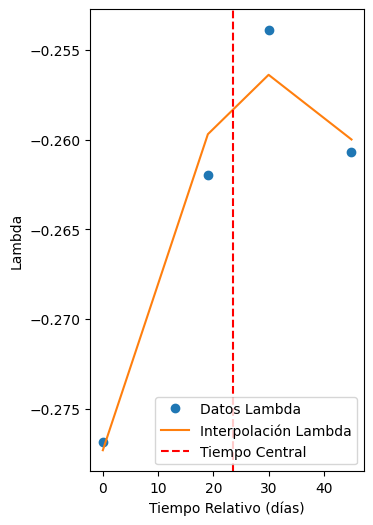

In [71]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_7, rho_7[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_7, np.polyval(poly_lambda_7, tiempo_relativo_7), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_7, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [72]:
#Para lambda

l_val_7 = np.polyval(poly_lambda_7, tiempo_central_reescalado_7)

derivada_1_l_7 = np.polyder(poly_lambda_7,1)
l_dval_7 = np.polyval(derivada_1_l_7, tiempo_central_reescalado_7)

derivada_2_l_7 = np.polyder(poly_lambda_7,2)
l_ddval_7 = np.polyval(derivada_2_l_7, tiempo_central_reescalado_7)

#Para mu

mu_val_7 = np.polyval(poly_mu_7, tiempo_central_reescalado_7)

derivada_1_mu_7 = np.polyder(poly_mu_7,1)
mu_dval_7 = np.polyval(derivada_1_mu_7, tiempo_central_reescalado_7)

derivada_2_mu_7 = np.polyder(poly_mu_7,2)
mu_ddval_7 = np.polyval(derivada_2_mu_7, tiempo_central_reescalado_7)

#Para nu

nu_val_7 = np.polyval(poly_nu_7, tiempo_central_reescalado_7)

derivada_1_nu_7 = np.polyder(poly_nu_7,1)
nu_dval_7 = np.polyval(derivada_1_nu_7, tiempo_central_reescalado_7)

derivada_2_nu_7 = np.polyder(poly_nu_7,2)
nu_ddval_7 = np.polyval(derivada_2_nu_7, tiempo_central_reescalado_7)

In [73]:
X_7= -9.560206927483522e-01
Y_7 = 2.640757619855256e-01
Z_7 = -9.056560159715226e-06

R_7 = np.sqrt(X_7**2 + Y_7**2 + Z_7**2)
print(R_7)

0.9918223495733984


In [74]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_7 = np.array([
    [l_val_7,  l_dval_7,  l_ddval_7],
    [mu_val_7, mu_dval_7, mu_ddval_7],
    [nu_val_7, nu_dval_7, nu_ddval_7]
])

# Calcular el determinante D
D_7 = np.linalg.det(matriz_D_7)
print(D_7)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_7 = np.array([
    [l_val_7, l_dval_7, X_7],
    [mu_val_7, mu_dval_7, Y_7],
    [nu_val_7, nu_dval_7, Z_7]
])

#Calcular el determiante D1
D1_7 = -k2* np.linalg.det(matriz_D1_7)
print(D1_7)

-2.2967235108865333e-09
-4.470321426920241e-09


In [75]:
#Intento preliminar
intento_7 = D1_7/D_7 * (1/(0.99)**3 - 1/(5.2)**3)
intento_7

np.float64(1.9921274060236818)

In [76]:
cos_phi_7 = (l_val_7*X_7 + mu_val_7*Y_7 +nu_val_7*Z_7)/(R_7)

# Bucle para hallar r y rho

r_obj_7 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_7 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_7 = (D1_7 / D_7) * (1/R_7**3 - 1/r_obj_7**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_7 = np.sqrt(rho_new_7**2 + R_7**2 + 2 * rho_new_7 * R_7 * cos_phi_7)
    
    print(f"{i:<5} | {rho_new_7:<15.8f} | {r_obj_7:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_7 - rho_old_7) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_7 = rho_new_7
    i += 1

rho_final_7 = rho_new_7
r_final_7 = r_obj_7

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_7:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_7:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 1.98109055      | 2.60949059     
1     | 1.88539573      | 2.51944673     
2     | 1.87322652      | 2.50802613     
3     | 1.87155632      | 2.50645923     
4     | 1.87132479      | 2.50624203     
5     | 1.87129265      | 2.50621188     
6     | 1.87128819      | 2.50620769     
7     | 1.87128757      | 2.50620711     
8     | 1.87128749      | 2.50620703     
9     | 1.87128747      | 2.50620702     
10    | 1.87128747      | 2.50620702     
----------------------------------------
¡Convergencia lograda en 10 iteraciones!

Distancia Tierra-Júpiter (rho): 1.871287 UA
Distancia Sol-Júpiter (r): 2.506207 UA


8va interpolación: 09/02; 28/02; 26/03

In [77]:
tiempos_uso_jd_8 = [tiempos_dias_jd[0],tiempos_dias_jd[1],tiempos_dias_jd[5]]  
print(tiempos_uso_jd_8)

tiempo_central_8 = np.mean(tiempos_uso_jd_8)
print(tiempo_central_8)

#Construcción del vector rho

alpha_8 = [alpha[0],alpha[1],alpha[5]]
delta_8 = [delta[0],delta[1],delta[5]]

rho_8 = np.zeros((3, 3))

for i in range(3):
    rho_8[i, 0] = np.cos(delta_8[i]) * np.cos(alpha_8[i])  # x
    rho_8[i, 1] = np.cos(delta_8[i]) * np.sin(alpha_8[i])  # y
    rho_8[i, 2] = np.sin(delta_8[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461100.509722222), np.float64(2461126.504166667)]
2461102.8370370367


In [78]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_8 = tiempos_uso_jd_8 - tiempos_uso_jd_8[0]

poly_lambda_8 = np.polyfit(tiempo_relativo_8, rho_8[:, 0], 2)
poly_mu_8 = np.polyfit(tiempo_relativo_8, rho_8[:, 1], 2)
poly_nu_8 = np.polyfit(tiempo_relativo_8, rho_8[:, 2], 2)

tiempo_central_reescalado_8 = tiempo_central_8 - tiempos_uso_jd_8[0] 

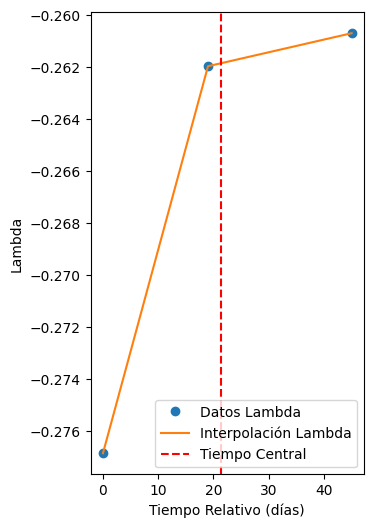

In [79]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_8, rho_8[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_8, np.polyval(poly_lambda_8, tiempo_relativo_8), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_8, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [80]:
#Para lambda

l_val_8 = np.polyval(poly_lambda_8, tiempo_central_reescalado_8)

derivada_1_l_8 = np.polyder(poly_lambda_8,1)
l_dval_8 = np.polyval(derivada_1_l_8, tiempo_central_reescalado_8)

derivada_2_l_8 = np.polyder(poly_lambda_8,2)
l_ddval_8 = np.polyval(derivada_2_l_8, tiempo_central_reescalado_8)

#Para mu

mu_val_8 = np.polyval(poly_mu_8, tiempo_central_reescalado_8)

derivada_1_mu_8 = np.polyder(poly_mu_8,1)
mu_dval_8 = np.polyval(derivada_1_mu_8, tiempo_central_reescalado_8)

derivada_2_mu_8 = np.polyder(poly_mu_8,2)
mu_ddval_8 = np.polyval(derivada_2_mu_8, tiempo_central_reescalado_8)

#Para nu

nu_val_8 = np.polyval(poly_nu_8, tiempo_central_reescalado_8)

derivada_1_nu_8 = np.polyder(poly_nu_8,1)
nu_dval_8 = np.polyval(derivada_1_nu_8, tiempo_central_reescalado_8)

derivada_2_nu_8 = np.polyder(poly_nu_8,2)
nu_ddval_8 = np.polyval(derivada_2_nu_8, tiempo_central_reescalado_8)

In [81]:
X_8= -9.448175510871250e-01
Y_8 = 2.999248903362722e-01
Z_8 = -1.264393001750415e-05

R_8 = np.sqrt(X_8**2 + Y_8**2 + Z_8**2)
print(R_8)

0.9912795492924111


In [82]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_8 = np.array([
    [l_val_8,  l_dval_8,  l_ddval_8],
    [mu_val_8, mu_dval_8, mu_ddval_8],
    [nu_val_8, nu_dval_8, nu_ddval_8]
])

# Calcular el determinante D
D_8 = np.linalg.det(matriz_D_8)
print(D_8)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_8 = np.array([
    [l_val_8, l_dval_8, X_8],
    [mu_val_8, mu_dval_8, Y_8],
    [nu_val_8, nu_dval_8, Z_8]
])

#Calcular el determiante D1
D1_8 = -k2* np.linalg.det(matriz_D1_8)
print(D1_8)

-1.1444822220808222e-09
-6.8413177777882445e-09


In [83]:
#Intento preliminar
intento_8 = D1_8/D_8 * (1/(0.99)**3 - 1/(5.2)**3)
intento_8

np.float64(6.118117143183229)

In [84]:
cos_phi_8 = (l_val_8*X_8 + mu_val_8*Y_8 +nu_val_8*Z_8)/(R_8)

# Bucle para hallar r y rho

r_obj_8 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_8 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_8 = (D1_8 / D_8) * (1/R_8**3 - 1/r_obj_8**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_8 = np.sqrt(rho_new_8**2 + R_8**2 + 2 * rho_new_8 * R_8 * cos_phi_8)
    
    print(f"{i:<5} | {rho_new_8:<15.8f} | {r_obj_8:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_8 - rho_old_8) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_8 = rho_new_8
    i += 1

rho_final_8 = rho_new_8
r_final_8 = r_obj_8

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_8:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_8:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 6.09429139      | 6.65995520     
1     | 6.11656866      | 6.68205121     
2     | 6.11676874      | 6.68224967     
3     | 6.11677052      | 6.68225144     
4     | 6.11677054      | 6.68225145     
5     | 6.11677054      | 6.68225145     
----------------------------------------
¡Convergencia lograda en 5 iteraciones!

Distancia Tierra-Júpiter (rho): 6.116771 UA
Distancia Sol-Júpiter (r): 6.682251 UA


In [85]:
#Finalmente, el vectoor de jupiter es

x_jup_8 = X_8 + rho_final_8 * l_val_8
y_jup_8 = Y_8 + rho_final_8 * mu_val_8
z_jup_8 = Z_8 + rho_final_8 * nu_val_8

vector_r_jupiter_8 = np.array([x_jup_8, y_jup_8, z_jup_8])
vector_r_jupiter_8

array([-2.54100377,  5.69930749,  2.39045843])

In [86]:
np.linalg.norm(vector_r_jupiter_8)

np.float64(6.682297323603285)

9na interpolacion: 28/02,11/03,26/03

In [87]:
tiempos_uso_jd_9 = [tiempos_dias_jd[1],tiempos_dias_jd[3],tiempos_dias_jd[5]]  
print(tiempos_uso_jd_9)

tiempo_central_9 = np.mean(tiempos_uso_jd_9)
print(tiempo_central_9)

#Construcción del vector rho

alpha_9 = [alpha[1],alpha[3],alpha[5]]
delta_9 = [delta[1],delta[3],delta[5]]

rho_9 = np.zeros((3, 3))

for i in range(3):
    rho_9[i, 0] = np.cos(delta_9[i]) * np.cos(alpha_9[i])  # x
    rho_9[i, 1] = np.cos(delta_9[i]) * np.sin(alpha_9[i])  # y
    rho_9[i, 2] = np.sin(delta_9[i])                     # z

[np.float64(2461100.509722222), np.float64(2461111.501388889), np.float64(2461126.504166667)]
2461112.8384259255


In [88]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_9 = tiempos_uso_jd_9 - tiempos_uso_jd_9[0]

poly_lambda_9 = np.polyfit(tiempo_relativo_9, rho_9[:, 0], 2)
poly_mu_9 = np.polyfit(tiempo_relativo_9, rho_9[:, 1], 2)
poly_nu_9 = np.polyfit(tiempo_relativo_9, rho_9[:, 2], 2)

tiempo_central_reescalado_9 = tiempo_central_9 - tiempos_uso_jd_9[0] 

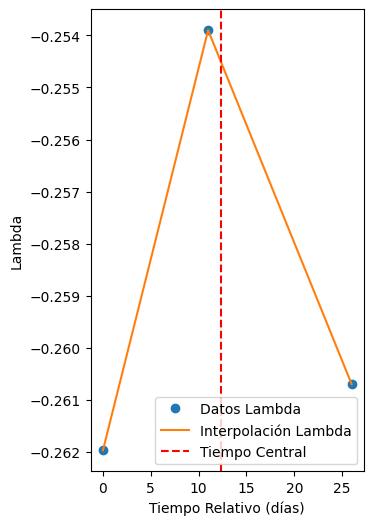

In [89]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_9, rho_9[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_9, np.polyval(poly_lambda_9, tiempo_relativo_9), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_9, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [90]:
#Para lambda

l_val_9 = np.polyval(poly_lambda_9, tiempo_central_reescalado_9)

derivada_1_l_9 = np.polyder(poly_lambda_9,1)
l_dval_9 = np.polyval(derivada_1_l_9, tiempo_central_reescalado_9)

derivada_2_l_9 = np.polyder(poly_lambda_9,2)
l_ddval_9 = np.polyval(derivada_2_l_9, tiempo_central_reescalado_9)

#Para mu

mu_val_9 = np.polyval(poly_mu_9, tiempo_central_reescalado_9)

derivada_1_mu_9 = np.polyder(poly_mu_9,1)
mu_dval_9 = np.polyval(derivada_1_mu_9, tiempo_central_reescalado_9)

derivada_2_mu_9 = np.polyder(poly_mu_9,2)
mu_ddval_9 = np.polyval(derivada_2_mu_9, tiempo_central_reescalado_9)

#Para nu

nu_val_9 = np.polyval(poly_nu_9, tiempo_central_reescalado_9)

derivada_1_nu_9 = np.polyder(poly_nu_9,1)
nu_dval_9 = np.polyval(derivada_1_nu_9, tiempo_central_reescalado_9)

derivada_2_nu_9 = np.polyder(poly_nu_9,2)
nu_ddval_9 = np.polyval(derivada_2_nu_9, tiempo_central_reescalado_9)

In [91]:
X_9 = -9.851535867039268e-01
Y_9 = 1.316147881709701e-01
Z_9 = 1.573017050180500E-08

R_9 = np.sqrt(X_9**2 + Y_9**2 + Z_9**2)
print(R_9)

0.993906455286865


In [92]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_9 = np.array([
    [l_val_9,  l_dval_9,  l_ddval_9],
    [mu_val_9, mu_dval_9, mu_ddval_9],
    [nu_val_9, nu_dval_9, nu_ddval_9]
])

# Calcular el determinante D
D_9 = np.linalg.det(matriz_D_9)
print(D_9)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_9 = np.array([
    [l_val_9, l_dval_9, X_9],
    [mu_val_9, mu_dval_9, Y_9],
    [nu_val_9, nu_dval_9, Z_9]
])

#Calcular el determiante D1
D1_9 = k2* np.linalg.det(matriz_D1_9)
print(D1_9)

-4.1852505673631724e-09
-3.730774106495592e-09


In [93]:
#Intento preliminar
intento_9 = D1_9/D_9 * (1/(0.99)**3 - 1/(5.2)**3)
intento_9

np.float64(0.9123564888713762)

In [94]:
cos_phi_9 = (l_val_9*X_9 + mu_val_9*Y_9 +nu_val_9*Z_9)/(R_9)

# Bucle para hallar r y rho

r_obj_9 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_9 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_9 = (D1_9 / D_9) * (1/R_9**3 - 1/r_obj_9**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_9 = np.sqrt(rho_new_9**2 + R_9**2 + 2 * rho_new_9 * R_9 * cos_phi_9)
    
    print(f"{i:<5} | {rho_new_9:<15.8f} | {r_obj_9:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_9 - rho_old_9) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_9 = rho_new_9
    i += 1

rho_final_9 = rho_new_9
r_final_9 = r_obj_9

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_9:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_9:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 0.90156646      | 1.56886044     
1     | 0.67705898      | 1.39369832     
2     | 0.57862174      | 1.32161125     
3     | 0.52174701      | 1.28156014     
4     | 0.48439922      | 1.25596628     
5     | 0.45797760      | 1.23822086     
6     | 0.43835474      | 1.22524407     
7     | 0.42327686      | 1.21539404     
8     | 0.41139822      | 1.20770999     
9     | 0.40186071      | 1.20158980     
10    | 0.39408877      | 1.19663563     
11    | 0.38768057      | 1.19257340     
12    | 0.38234635      | 1.18920771     
13    | 0.37787140      | 1.18639534     
14    | 0.37409309      | 1.18402874     
15    | 0.37088578      | 1.18202557     
16    | 0.36815089      | 1.18032164     
17    | 0.36580992      | 1.17886623     
18    | 0.36379965      | 1.17761869     
19    | 0.36206858      | 1.17654611     
20    | 0.36057440      | 1.17562158     
21    | 0.35928209      | 1.1748228

10 Interpolación: 9/02, 02/03, 6/04

In [142]:
tiempos_uso_jd_10 = [tiempos_dias_jd[0],tiempos_dias_jd[2],tiempos_dias_jd[6]]  
print(tiempos_uso_jd_10)

tiempo_central_10 = np.mean(tiempos_uso_jd_10)
print(tiempo_central_10)

#Construcción del vector rho

alpha_10 = [alpha[0],alpha[2],alpha[6]]
delta_10 = [delta[0],delta[2],delta[6]]

rho_10 = np.zeros((3, 3))

for i in range(3):
    rho_10[i, 0] = np.cos(delta_10[i]) * np.cos(alpha_10[i])  # x
    rho_10[i, 1] = np.cos(delta_10[i]) * np.sin(alpha_10[i])  # y
    rho_10[i, 2] = np.sin(delta_10[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461102.476388889), np.float64(2461137.5083333333)]
2461107.160648148


In [143]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_10 = tiempos_uso_jd_10 - tiempos_uso_jd_10[0]

poly_lambda_10 = np.polyfit(tiempo_relativo_10, rho_10[:, 0], 2)
poly_mu_10 = np.polyfit(tiempo_relativo_10, rho_10[:, 1], 2)
poly_nu_10 = np.polyfit(tiempo_relativo_10, rho_10[:, 2], 2)

tiempo_central_reescalado_10 = tiempo_central_10 - tiempos_uso_jd_10[0] 

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Jessi Dani\AppData\Local\Temp\ipykernel_19052\2989291061.py:3: SyntaxWarning: invalid escape sequence '\l'
  nombres = ['Lambda ($\lambda$)', 'Mu ($\mu$)', 'Nu ($\\nu$)']
C:\Users\Jessi Dani\AppData\Local\Temp\ipykernel_19052\2989291061.py:3: SyntaxWarning: invalid escape sequence '\m'
  nombres = ['Lambda ($\lambda$)', 'Mu ($\mu$)', 'Nu ($\\nu$)']


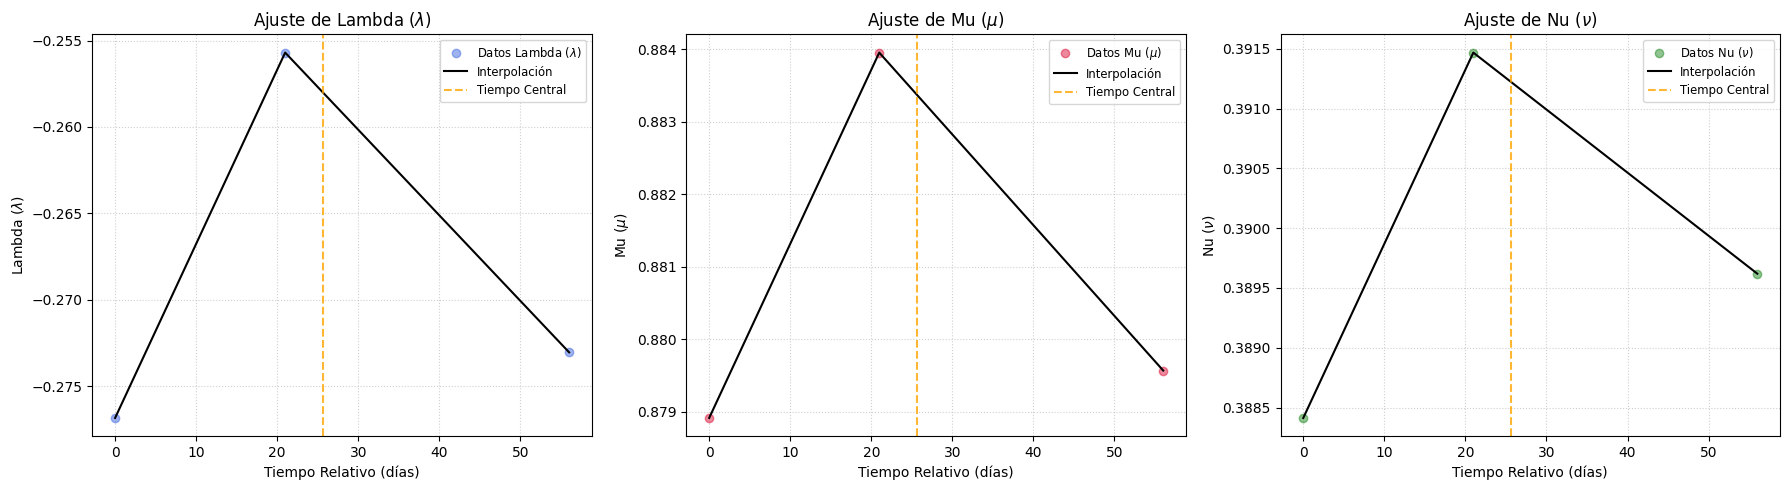

In [311]:
# Definimos las listas de datos para iterar y no repetir código
polinomios_10 = [poly_lambda_10, poly_mu_10, poly_nu_10]
nombres = ['Lambda ($\lambda$)', 'Mu ($\mu$)', 'Nu ($\\nu$)']
colores = ['royalblue', 'crimson', 'forestgreen']

plt.figure(figsize=(18, 5)) # Un ancho mayor para que quepan las tres

for i in range(3):
    plt.subplot(1, 3, i + 1)
    
    # 1. Graficar los datos originales (puntos)
    plt.plot(tiempo_relativo_10, rho_10[:, i], 'o', color=colores[i], 
             alpha=0.5, label=f'Datos {nombres[i]}')
    
    # 2. Graficar la interpolación (línea continua)
    # Suponiendo que tienes poly_lambda, poly_mu y poly_nu ya definidos
    plt.plot(tiempo_relativo_10, np.polyval(polinomios_10[i], tiempo_relativo_10), 
             '-', color='black', linewidth=1.5, label='Interpolación')
    
    # 3. Marcar el tiempo central
    plt.axvline(tiempo_central_reescalado_10, color='orange', linestyle='--', 
                label='Tiempo Central', alpha=0.8)
    
    plt.xlabel('Tiempo Relativo (días)')
    plt.ylabel(nombres[i])
    plt.title(f'Ajuste de {nombres[i]}')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize='small')

    # Importante para ver las variaciones pequeñas (quita el offset)
    plt.gca().ticklabel_format(useOffset=False)
plt.tight_layout()
plt.show()

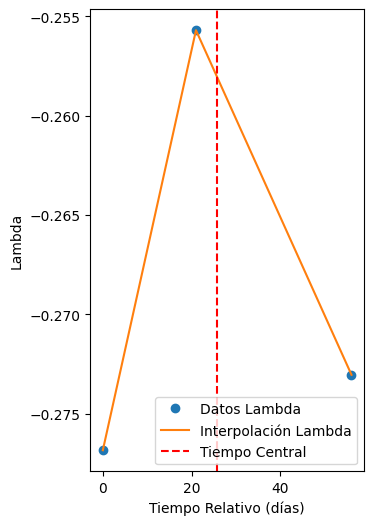

In [144]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_10, rho_10[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_10, np.polyval(poly_lambda_10, tiempo_relativo_10), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_10, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [145]:
#Para lambda

l_val_10 = np.polyval(poly_lambda_10, tiempo_central_reescalado_10)

derivada_1_l_10 = np.polyder(poly_lambda_10,1)
l_dval_10 = np.polyval(derivada_1_l_10, tiempo_central_reescalado_10)

derivada_2_l_10 = np.polyder(poly_lambda_10,2)
l_ddval_10 = np.polyval(derivada_2_l_10, tiempo_central_reescalado_10)

#Para mu

mu_val_10 = np.polyval(poly_mu_10, tiempo_central_reescalado_10)

derivada_1_mu_10 = np.polyder(poly_mu_10,1)
mu_dval_10 = np.polyval(derivada_1_mu_10, tiempo_central_reescalado_10)

derivada_2_mu_10 = np.polyder(poly_mu_10,2)
mu_ddval_10 = np.polyval(derivada_2_mu_10, tiempo_central_reescalado_10)

#Para nu

nu_val_10 = np.polyval(poly_nu_10, tiempo_central_reescalado_10)

derivada_1_nu_10 = np.polyder(poly_nu_10,1)
nu_dval_10 = np.polyval(derivada_1_nu_10, tiempo_central_reescalado_10)

derivada_2_nu_10 = np.polyder(poly_nu_10,2)
nu_ddval_10 = np.polyval(derivada_2_nu_10, tiempo_central_reescalado_10)

In [146]:
X_10 = -9.940111185719906E-01
Y_10 = 4.923066405959067E-02
Z_10 = 2.241584389104348E-06

R_10 = np.sqrt(X_10**2 + Y_10**2 + Z_10**2)
print(R_10)

#18 de marzo

0.9952295022423285


In [152]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_10 = np.array([
    [l_val_10,  l_dval_10,  l_ddval_10],
    [mu_val_10, mu_dval_10, mu_ddval_10],
    [nu_val_10, nu_dval_10, nu_ddval_10]
])

# Calcular el determinante D
D_10 = np.linalg.det(matriz_D_10)
print(D_10)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_10 = np.array([
    [l_val_10, l_dval_10, X_10],
    [mu_val_10, mu_dval_10, Y_10],
    [nu_val_10, nu_dval_10, Z_10]
])

#Calcular el determiante D1
D1_10 = k2* np.linalg.det(matriz_D1_10)
print(D1_10)

-7.485387065196858e-10
-3.8050550316352505e-09


In [153]:
#Intento preliminar
intento_10 = D1_10/D_10 * (1/(0.99)**3 - 1/(5.2)**3)
intento_10

np.float64(5.202759550773686)

In [ ]:
cos_phi_10 = (l_val_10*X_10 + mu_val_10*Y_10 +nu_val_10*Z_10)/(R_10)

# Bucle para hallar r y rho

r_obj_10 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_10 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_10 = (D1_10 / D_10) * (1/R_10**3 - 1/r_obj_10**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_10 = np.sqrt(rho_new_10**2 + R_10**2 + 2 * rho_new_10 * R_10 * cos_phi_10)
    
    print(f"{i:<5} | {rho_new_10:<15.8f} | {r_obj_10:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_10 - rho_old_10) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_10 = rho_new_10
    i += 1

rho_final_10 = rho_new_10
r_final_10 = r_obj_10

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_10:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_10:.6f} UA")

#El error es de aproximadamente una unidad astronómica

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 5.12060806      | 5.49951891     
1     | 5.12619907      | 5.50502593     
2     | 5.12629069      | 5.50511618     
3     | 5.12629219      | 5.50511766     
4     | 5.12629222      | 5.50511768     
5     | 5.12629222      | 5.50511768     
----------------------------------------
¡Convergencia lograda en 5 iteraciones!

Distancia Tierra-Júpiter (rho): 5.126292 UA
Distancia Sol-Júpiter (r): 5.505118 UA


In [155]:
#Finalmente, el vectoor de jupiter es

x_jup_10 = X_10 + rho_final_10 * l_val_10
y_jup_10 = Y_10 + rho_final_10 * mu_val_10
z_jup_10 = Z_10 + rho_final_10 * nu_val_10

vector_r_jupiter_10 = np.array([x_jup_10, y_jup_10, z_jup_10])
vector_r_jupiter_10

array([-2.29712451,  4.58237727,  2.00809173])

In [156]:
np.linalg.norm(vector_r_jupiter_10)

np.float64(5.505215237814385)

11 Interpolación: 09/02, 11/03, 06/04

In [157]:
tiempos_uso_jd_11 = [tiempos_dias_jd[0],tiempos_dias_jd[3],tiempos_dias_jd[6]]  
print(tiempos_uso_jd_11)

tiempo_central_11 = np.mean(tiempos_uso_jd_11)
print(tiempo_central_11)

#Construcción del vector rho

alpha_11 = [alpha[0],alpha[3],alpha[6]]
delta_11 = [delta[0],delta[3],delta[6]]

rho_11 = np.zeros((3, 3))

for i in range(3):
    rho_11[i, 0] = np.cos(delta_11[i]) * np.cos(alpha_11[i])  # x
    rho_11[i, 1] = np.cos(delta_11[i]) * np.sin(alpha_11[i])  # y
    rho_11[i, 2] = np.sin(delta_11[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461111.501388889), np.float64(2461137.5083333333)]
2461110.1689814813


In [158]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_11 = tiempos_uso_jd_11 - tiempos_uso_jd_11[0]

poly_lambda_11 = np.polyfit(tiempo_relativo_11, rho_11[:, 0], 2)
poly_mu_11 = np.polyfit(tiempo_relativo_11, rho_11[:, 1], 2)
poly_nu_11 = np.polyfit(tiempo_relativo_11, rho_11[:, 2], 2)

tiempo_central_reescalado_11 = tiempo_central_11 - tiempos_uso_jd_11[0] 

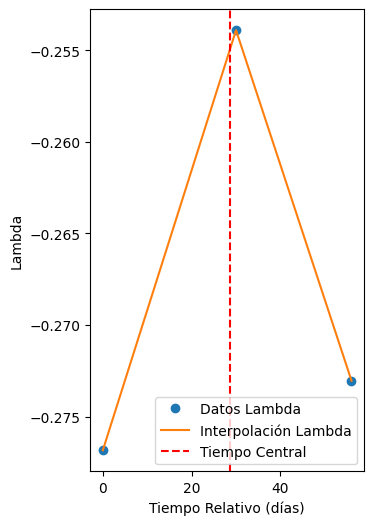

In [162]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_11, rho_11[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_11, np.polyval(poly_lambda_11, tiempo_relativo_11), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_11, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [188]:
X_11 = -9.772533004143044E-01
Y_11 = 1.771506397808046E-01
Z_11 = -2.186951552737587E-06

R_11 = np.sqrt(X_11**2 + Y_11**2 + Z_11**2)
print(R_11)

#10 de marzo

0.9931799244599046


In [195]:
#Para lambda

l_val_11 = np.polyval(poly_lambda_11, tiempo_central_reescalado_11)

derivada_1_l_11 = np.polyder(poly_lambda_11,1)
l_dval_11 = np.polyval(derivada_1_l_11, tiempo_central_reescalado_11)

derivada_2_l_11 = np.polyder(poly_lambda_11,2)
l_ddval_11 = np.polyval(derivada_2_l_11, tiempo_central_reescalado_11)

#Para mu

mu_val_11 = np.polyval(poly_mu_11, tiempo_central_reescalado_11)

derivada_1_mu_11 = np.polyder(poly_mu_11,1)
mu_dval_11 = np.polyval(derivada_1_mu_11, tiempo_central_reescalado_11)

derivada_2_mu_11 = np.polyder(poly_mu_11,2)
mu_ddval_11 = np.polyval(derivada_2_mu_11, tiempo_central_reescalado_11)

#Para nu

nu_val_11 = np.polyval(poly_nu_11, tiempo_central_reescalado_11)

derivada_1_nu_11 = np.polyder(poly_nu_11,1)
nu_dval_11 = np.polyval(derivada_1_nu_11, tiempo_central_reescalado_11)

derivada_2_nu_11 = np.polyder(poly_nu_11,2)
nu_ddval_11 = np.polyval(derivada_2_nu_11, tiempo_central_reescalado_11)

In [201]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_11 = np.array([
    [l_val_11,  l_dval_11,  l_ddval_11],
    [mu_val_11, mu_dval_11, mu_ddval_11],
    [nu_val_11, nu_dval_11, nu_ddval_11]
])

# Calcular el determinante D
D_11 = np.linalg.det(matriz_D_11)
print(D_11)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_11 = np.array([
    [l_val_11, l_dval_11, X_11],
    [mu_val_11, mu_dval_11, Y_11],
    [nu_val_11, nu_dval_11, Z_11]
])

#Calcular el determiante D1
D1_11 = k2* np.linalg.det(matriz_D1_11)
print(D1_11)

#Intento preliminar
intento_11 = D1_11/D_11 * (1/(0.99)**3 - 1/(5.2)**3)
print(intento_11)

-1.0405520313835496e-09
-3.827695379282458e-09
3.7649623862634254


In [ ]:
cos_phi_11 = (l_val_11*X_11 + mu_val_11*Y_11 +nu_val_11*Z_11)/(R_11)

# Bucle para hallar r y rho

r_obj_11 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_11 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_11 = (D1_11 / D_11) * (1/R_11**3 - 1/r_obj_11**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_11 = np.sqrt(rho_new_11**2 + R_11**2 + 2 * rho_new_11 * R_11 * cos_phi_11)
    
    print(f"{i:<5} | {rho_new_11:<15.8f} | {r_obj_11:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_11 - rho_old_11) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_11 = rho_new_11
    i += 1

rho_final_11 = rho_new_11
r_final_11 = r_obj_11

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_11:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_11:.6f} UA")

#El error es de una unidad astronomica y medio.

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 3.72866404      | 4.23187827     
1     | 3.70628847      | 4.21002527     
2     | 3.70552871      | 4.20928336     
3     | 3.70550264      | 4.20925790     
4     | 3.70550174      | 4.20925702     
5     | 3.70550171      | 4.20925699     
6     | 3.70550171      | 4.20925699     
----------------------------------------
¡Convergencia lograda en 6 iteraciones!

Distancia Tierra-Júpiter (rho): 3.705502 UA
Distancia Sol-Júpiter (r): 4.209257 UA


12 Interpolación: 28/02, 26/03, 30/04

In [160]:
tiempos_uso_jd_12 = [tiempos_dias_jd[1],tiempos_dias_jd[5],tiempos_dias_jd[7]]  
print(tiempos_uso_jd_12)

tiempo_central_12 = np.mean(tiempos_uso_jd_12)
print(tiempo_central_12)

#Construcción del vector rho

alpha_12 = [alpha[1],alpha[5],alpha[7]]
delta_12 = [delta[1],delta[5],delta[7]]

rho_12 = np.zeros((3, 3))

for i in range(3):
    rho_12[i, 0] = np.cos(delta_12[i]) * np.cos(alpha_12[i])  # x
    rho_12[i, 1] = np.cos(delta_12[i]) * np.sin(alpha_12[i])  # y
    rho_12[i, 2] = np.sin(delta_12[i])                     # z

[np.float64(2461100.509722222), np.float64(2461126.504166667), np.float64(2461161.4909722223)]
2461129.5016203704


In [161]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_12 = tiempos_uso_jd_12 - tiempos_uso_jd_12[0]

poly_lambda_12 = np.polyfit(tiempo_relativo_12, rho_12[:, 0], 2)
poly_mu_12 = np.polyfit(tiempo_relativo_12, rho_12[:, 1], 2)
poly_nu_12 = np.polyfit(tiempo_relativo_12, rho_12[:, 2], 2)

tiempo_central_reescalado_12 = tiempo_central_12 - tiempos_uso_jd_12[0] 

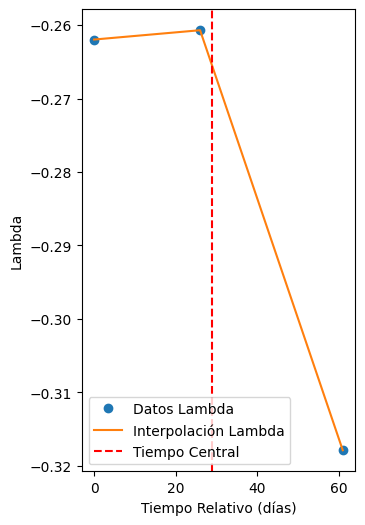

In [163]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_12, rho_12[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_12, np.polyval(poly_lambda_12, tiempo_relativo_12), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_12, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [189]:
X_12 = -9.863921920181568E-01
Y_12 = -1.551699938717052E-01
Z_12 = 1.448043744217673E-05

R_12 = np.sqrt(X_12**2 + Y_12**2 + Z_12**2)
print(R_12)

#30 de marzo

0.9985225504124643


In [196]:
#Para lambda

l_val_12 = np.polyval(poly_lambda_12, tiempo_central_reescalado_12)

derivada_1_l_12 = np.polyder(poly_lambda_12,1)
l_dval_12 = np.polyval(derivada_1_l_12, tiempo_central_reescalado_12)

derivada_2_l_12 = np.polyder(poly_lambda_12,2)
l_ddval_12 = np.polyval(derivada_2_l_12, tiempo_central_reescalado_12)

#Para mu

mu_val_12 = np.polyval(poly_mu_12, tiempo_central_reescalado_12)

derivada_1_mu_12 = np.polyder(poly_mu_12,1)
mu_dval_12 = np.polyval(derivada_1_mu_12, tiempo_central_reescalado_12)

derivada_2_mu_12 = np.polyder(poly_mu_12,2)
mu_ddval_12 = np.polyval(derivada_2_mu_12, tiempo_central_reescalado_12)

#Para nu

nu_val_12 = np.polyval(poly_nu_12, tiempo_central_reescalado_12)

derivada_1_nu_12 = np.polyder(poly_nu_12,1)
nu_dval_12 = np.polyval(derivada_1_nu_12, tiempo_central_reescalado_12)

derivada_2_nu_12 = np.polyder(poly_nu_12,2)
nu_ddval_12 = np.polyval(derivada_2_nu_12, tiempo_central_reescalado_12)

In [203]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_12 = np.array([
    [l_val_12,  l_dval_12,  l_ddval_12],
    [mu_val_12, mu_dval_12, mu_ddval_12],
    [nu_val_12, nu_dval_12, nu_ddval_12]
])

# Calcular el determinante D
D_12 = np.linalg.det(matriz_D_12)
print(D_12)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_12 = np.array([
    [l_val_12, l_dval_12, X_12],
    [mu_val_12, mu_dval_12, Y_12],
    [nu_val_12, nu_dval_12, Z_12]
])

#Calcular el determiante D1
D1_12 =- k2* np.linalg.det(matriz_D1_12)
print(D1_12)

#Intento preliminar
intento_12 = D1_12/D_12 * (1/(0.99)**3 - 1/(5.2)**3)
print(intento_12)

-1.8071924291673278e-09
-1.819069385945245e-08
10.302246612203431


In [ ]:
cos_phi_12 = (l_val_12*X_12 + mu_val_12*Y_12 +nu_val_12*Z_12)/(R_12)

# Bucle para hallar r y rho

r_obj_12 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_12 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_12 = (D1_12 / D_12) * (1/R_12**3 - 1/r_obj_12**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_12 = np.sqrt(rho_new_12**2 + R_12**2 + 2 * rho_new_12 * R_12 * cos_phi_12)
    
    print(f"{i:<5} | {rho_new_12:<15.8f} | {r_obj_12:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_12 - rho_old_12) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_12 = rho_new_12
    i += 1

rho_final_12 = rho_new_12
r_final_12 = r_obj_12

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_12:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_12:.6f} UA")

#De esta medida podemos descrubir que los datos con mayor incertidumbre son el 28 de febrero y el 30 de abril.

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 10.03888032     | 10.20962949    
1     | 10.10100909     | 10.27146668    
2     | 10.10117889     | 10.27163569    
3     | 10.10117935     | 10.27163614    
4     | 10.10117935     | 10.27163615    
----------------------------------------
¡Convergencia lograda en 4 iteraciones!

Distancia Tierra-Júpiter (rho): 10.101179 UA
Distancia Sol-Júpiter (r): 10.271636 UA


13 Interpolación: 09/02, 02/03, 30/04

In [164]:
tiempos_uso_jd_13 = [tiempos_dias_jd[0],tiempos_dias_jd[2],tiempos_dias_jd[7]]  
print(tiempos_uso_jd_13)

tiempo_central_13 = np.mean(tiempos_uso_jd_13)
print(tiempo_central_13)

#Construcción del vector rho

alpha_13 = [alpha[0],alpha[2],alpha[7]]
delta_13 = [delta[0],delta[2],delta[7]]

rho_13 = np.zeros((3, 3))

for i in range(3):
    rho_13[i, 0] = np.cos(delta_13[i]) * np.cos(alpha_13[i])  # x
    rho_13[i, 1] = np.cos(delta_13[i]) * np.sin(alpha_13[i])  # y
    rho_13[i, 2] = np.sin(delta_13[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461102.476388889), np.float64(2461161.4909722223)]
2461115.154861111


In [165]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_13 = tiempos_uso_jd_13 - tiempos_uso_jd_13[0]

poly_lambda_13 = np.polyfit(tiempo_relativo_13, rho_13[:, 0], 2)
poly_mu_13 = np.polyfit(tiempo_relativo_13, rho_13[:, 1], 2)
poly_nu_13 = np.polyfit(tiempo_relativo_13, rho_13[:, 2], 2)

tiempo_central_reescalado_13 = tiempo_central_13 - tiempos_uso_jd_13[0] 

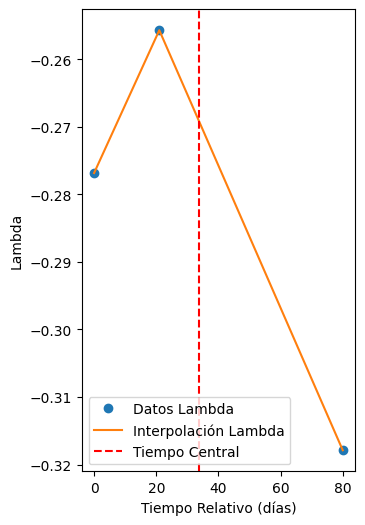

In [166]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_13, rho_13[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_13, np.polyval(poly_lambda_13, tiempo_relativo_13), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_13, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [191]:
X_13 = -9.902932851425371E-01
Y_13 = 9.185963450218064E-02
Z_13 = 1.268373245391874E-06

R_13 = np.sqrt(X_13**2 + Y_13**2 + Z_13**2)
print(R_13)

#15 de marzo

0.9945446108902714


In [197]:
#Para lambda

l_val_13 = np.polyval(poly_lambda_13, tiempo_central_reescalado_13)

derivada_1_l_13 = np.polyder(poly_lambda_13,1)
l_dval_13 = np.polyval(derivada_1_l_13, tiempo_central_reescalado_13)

derivada_2_l_13 = np.polyder(poly_lambda_13,2)
l_ddval_13 = np.polyval(derivada_2_l_13, tiempo_central_reescalado_13)

#Para mu

mu_val_13 = np.polyval(poly_mu_13, tiempo_central_reescalado_13)

derivada_1_mu_13 = np.polyder(poly_mu_13,1)
mu_dval_13 = np.polyval(derivada_1_mu_13, tiempo_central_reescalado_13)

derivada_2_mu_13 = np.polyder(poly_mu_13,2)
mu_ddval_13 = np.polyval(derivada_2_mu_13, tiempo_central_reescalado_13)

#Para nu

nu_val_13 = np.polyval(poly_nu_13, tiempo_central_reescalado_13)

derivada_1_nu_13 = np.polyder(poly_nu_13,1)
nu_dval_13 = np.polyval(derivada_1_nu_13, tiempo_central_reescalado_13)

derivada_2_nu_13 = np.polyder(poly_nu_13,2)
nu_ddval_13 = np.polyval(derivada_2_nu_13, tiempo_central_reescalado_13)

In [205]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_13 = np.array([
    [l_val_13,  l_dval_13,  l_ddval_13],
    [mu_val_13, mu_dval_13, mu_ddval_13],
    [nu_val_13, nu_dval_13, nu_ddval_13]
])

# Calcular el determinante D
D_13 = np.linalg.det(matriz_D_13)
print(D_13)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_13 = np.array([
    [l_val_13, l_dval_13, X_13],
    [mu_val_13, mu_dval_13, Y_13],
    [nu_val_13, nu_dval_13, Z_13]
])

#Calcular el determiante D1
D1_13 = k2* np.linalg.det(matriz_D1_13)
print(D1_13)

#Intento preliminar
intento_13 = D1_13/D_13 * (1/(0.99)**3 - 1/(5.2)**3)
print(intento_13)

-6.185442972554137e-10
-4.096539606786737e-09
6.7784972808024335


In [243]:
cos_phi_13 = (l_val_13*X_13 + mu_val_13*Y_13 +nu_val_13*Z_13)/(R_13)

# Bucle para hallar r y rho

r_obj_13 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_13 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_13 = (D1_13 / D_13) * (1/R_13**3 - 1/r_obj_13**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_13 = np.sqrt(rho_new_13**2 + R_13**2 + 2 * rho_new_13 * R_13 * cos_phi_13)
    
    print(f"{i:<5} | {rho_new_13:<15.8f} | {r_obj_13:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_13 - rho_old_13) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_13 = rho_new_13
    i += 1

rho_final_13 = rho_new_13
r_final_13 = r_obj_13

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_13:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_13:.6f} UA")

#El error es de una unidad astronomica y medio.

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 6.68535467      | 7.08033767     
1     | 6.71379751      | 7.10853120     
2     | 6.71401864      | 7.10875041     
3     | 6.71402034      | 7.10875210     
4     | 6.71402036      | 7.10875211     
5     | 6.71402036      | 7.10875211     
----------------------------------------
¡Convergencia lograda en 5 iteraciones!

Distancia Tierra-Júpiter (rho): 6.714020 UA
Distancia Sol-Júpiter (r): 7.108752 UA


14 Interpolación: 09/02, 11/03, 30/04

In [167]:
tiempos_uso_jd_14 = [tiempos_dias_jd[0],tiempos_dias_jd[3],tiempos_dias_jd[7]]  
print(tiempos_uso_jd_14)

tiempo_central_14 = np.mean(tiempos_uso_jd_14)
print(tiempo_central_14)

#Construcción del vector rho

alpha_14 = [alpha[0],alpha[3],alpha[7]]
delta_14 = [delta[0],delta[3],delta[7]]

rho_14 = np.zeros((3, 3))

for i in range(3):
    rho_14[i, 0] = np.cos(delta_14[i]) * np.cos(alpha_14[i])  # x
    rho_14[i, 1] = np.cos(delta_14[i]) * np.sin(alpha_14[i])  # y
    rho_14[i, 2] = np.sin(delta_14[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461111.501388889), np.float64(2461161.4909722223)]
2461118.1631944445


In [168]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_14 = tiempos_uso_jd_14 - tiempos_uso_jd_14[0]

poly_lambda_14 = np.polyfit(tiempo_relativo_14, rho_14[:, 0], 2)
poly_mu_14 = np.polyfit(tiempo_relativo_14, rho_14[:, 1], 2)
poly_nu_14 = np.polyfit(tiempo_relativo_14, rho_14[:, 2], 2)

tiempo_central_reescalado_14 = tiempo_central_14 - tiempos_uso_jd_14[0] 

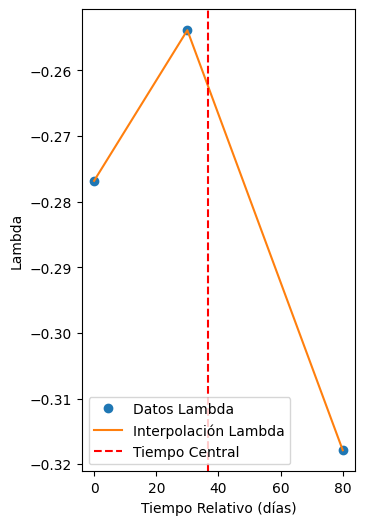

In [169]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_14, rho_14[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_14, np.polyval(poly_lambda_14, tiempo_relativo_14), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_14, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [192]:
X_14 = -9.945730502600652E-01
Y_14 = 4.000951936808515E-02
Z_14 = 2.447261227955545E-06

R_14 = np.sqrt(X_14**2 + Y_14**2 + Z_14**2)
print(R_14)

#18 de marzo

0.9953774730973494


In [198]:
#Para lambda

l_val_14 = np.polyval(poly_lambda_14, tiempo_central_reescalado_14)

derivada_1_l_14 = np.polyder(poly_lambda_14,1)
l_dval_14 = np.polyval(derivada_1_l_14, tiempo_central_reescalado_14)

derivada_2_l_14 = np.polyder(poly_lambda_14,2)
l_ddval_14 = np.polyval(derivada_2_l_14, tiempo_central_reescalado_14)

#Para mu

mu_val_14 = np.polyval(poly_mu_14, tiempo_central_reescalado_14)

derivada_1_mu_14 = np.polyder(poly_mu_14,1)
mu_dval_14 = np.polyval(derivada_1_mu_14, tiempo_central_reescalado_14)

derivada_2_mu_14 = np.polyder(poly_mu_14,2)
mu_ddval_14 = np.polyval(derivada_2_mu_14, tiempo_central_reescalado_14)

#Para nu

nu_val_14 = np.polyval(poly_nu_14, tiempo_central_reescalado_14)

derivada_1_nu_14 = np.polyder(poly_nu_14,1)
nu_dval_14 = np.polyval(derivada_1_nu_14, tiempo_central_reescalado_14)

derivada_2_nu_14 = np.polyder(poly_nu_14,2)
nu_ddval_14 = np.polyval(derivada_2_nu_14, tiempo_central_reescalado_14)

In [252]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_14 = np.array([
    [l_val_14,  l_dval_14,  l_ddval_14],
    [mu_val_14, mu_dval_14, mu_ddval_14],
    [nu_val_14, nu_dval_14, nu_ddval_14]
])

# Calcular el determinante D
D_14 = np.linalg.det(matriz_D_14)
print(D_14)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_14 = np.array([
    [l_val_14, l_dval_14, X_14],
    [mu_val_14, mu_dval_14, Y_14],
    [nu_val_14, nu_dval_14, Z_14]
])

#Calcular el determiante D1
D1_14 =- k2* np.linalg.det(matriz_D1_14)
print(D1_14)

#Intento preliminar
intento_14 = D1_14/D_14 * (1/(0.99)**3 - 1/(5.2)**3)
print(intento_14)

5.3985780746589e-10
5.43885740493097e-10
1.0311346034252915


In [245]:
cos_phi_14 = (l_val_14*X_14 + mu_val_14*Y_14 +nu_val_14*Z_14)/(R_14)

# Bucle para hallar r y rho

r_obj_14 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_14 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_14 = (D1_14 / D_14) * (1/R_14**3 - 1/r_obj_14**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_14 = np.sqrt(rho_new_14**2 + R_14**2 + 2 * rho_new_14 * R_14 * cos_phi_14)
    
    print(f"{i:<5} | {rho_new_14:<15.8f} | {r_obj_14:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_14 - rho_old_14) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_14 = rho_new_14
    i += 1

rho_final_14 = rho_new_14
r_final_14 = r_obj_14

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_14:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_14:.6f} UA")

#Se puede determinar que los datos del 11 de marzo y el 30 de Abril tienen una gran incertidumbre.

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 1.01439728      | 1.61438048     
1     | 0.78211465      | 1.43340083     
2     | 0.67948417      | 1.35841832     
3     | 0.61965334      | 1.31642785     
4     | 0.57995414      | 1.28934395     
5     | 0.55153627      | 1.27036382     
6     | 0.53015238      | 1.25631645     
7     | 0.51348343      | 1.24551114     
8     | 0.50014502      | 1.23695860     
9     | 0.48925456      | 1.23003884     
10    | 0.48022020      | 1.22434227     
11    | 0.47262879      | 1.21958671     
12    | 0.46618232      | 1.21557101     
13    | 0.46065993      | 1.21214763     
14    | 0.45589416      | 1.20920577     
15    | 0.45175548      | 1.20666046     
16    | 0.44814204      | 1.20444540     
17    | 0.44497254      | 1.20250806     
18    | 0.44218125      | 1.20080624     
19    | 0.43971440      | 1.19930563     
20    | 0.43752758      | 1.19797803     
21    | 0.43558375      | 1.1968000

15 Interpolación: 09/02, 19/03, 30/04

In [177]:
tiempos_uso_jd_15 = [tiempos_dias_jd[0],tiempos_dias_jd[4],tiempos_dias_jd[7]]  
print(tiempos_uso_jd_15)

tiempo_central_15 = np.mean(tiempos_uso_jd_15)
print(tiempo_central_15)

#Construcción del vector rho

alpha_15 = [alpha[0],alpha[4],alpha[7]]
delta_15 = [delta[0],delta[4],delta[7]]

rho_15 = np.zeros((3, 3))

for i in range(3):
    rho_15[i, 0] = np.cos(delta_15[i]) * np.cos(alpha_15[i])  # x
    rho_15[i, 1] = np.cos(delta_15[i]) * np.sin(alpha_15[i])  # y
    rho_15[i, 2] = np.sin(delta_15[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461119.543055556), np.float64(2461161.4909722223)]
2461120.84375


In [179]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_15 = tiempos_uso_jd_15 - tiempos_uso_jd_15[0]

poly_lambda_15 = np.polyfit(tiempo_relativo_15, rho_15[:, 0], 2)
poly_mu_15 = np.polyfit(tiempo_relativo_15, rho_15[:, 1], 2)
poly_nu_15 = np.polyfit(tiempo_relativo_15, rho_15[:, 2], 2)

tiempo_central_reescalado_15 = tiempo_central_15 - tiempos_uso_jd_15[0] 

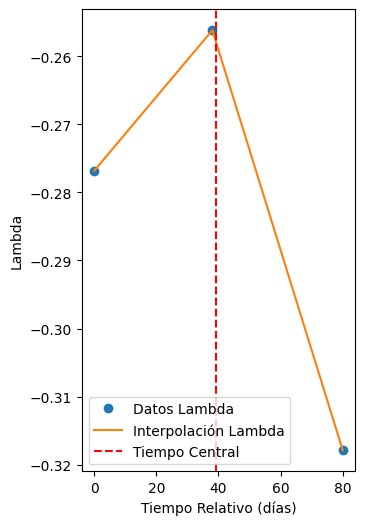

In [180]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_15, rho_15[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_15, np.polyval(poly_lambda_15, tiempo_relativo_15), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_15, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [193]:
X_15 = -9.960990273952756E-01
Y_15 = -6.288889701707800E-03
Z_15 = 3.756642342933999E-06

R_15 = np.sqrt(X_15**2 + Y_15**2 + Z_15**2)
print(R_15)

#21 de marzo

0.9961188797154719


In [199]:
#Para lambda

l_val_15 = np.polyval(poly_lambda_15, tiempo_central_reescalado_15)

derivada_1_l_15 = np.polyder(poly_lambda_15,1)
l_dval_15 = np.polyval(derivada_1_l_15, tiempo_central_reescalado_15)

derivada_2_l_15 = np.polyder(poly_lambda_15,2)
l_ddval_15 = np.polyval(derivada_2_l_15, tiempo_central_reescalado_15)

#Para mu

mu_val_15 = np.polyval(poly_mu_15, tiempo_central_reescalado_15)

derivada_1_mu_15 = np.polyder(poly_mu_15,1)
mu_dval_15 = np.polyval(derivada_1_mu_15, tiempo_central_reescalado_15)

derivada_2_mu_15 = np.polyder(poly_mu_15,2)
mu_ddval_15 = np.polyval(derivada_2_mu_15, tiempo_central_reescalado_15)

#Para nu

nu_val_15 = np.polyval(poly_nu_15, tiempo_central_reescalado_15)

derivada_1_nu_15 = np.polyder(poly_nu_15,1)
nu_dval_15 = np.polyval(derivada_1_nu_15, tiempo_central_reescalado_15)

derivada_2_nu_15 = np.polyder(poly_nu_15,2)
nu_ddval_15 = np.polyval(derivada_2_nu_15, tiempo_central_reescalado_15)

In [208]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_15 = np.array([
    [l_val_15,  l_dval_15,  l_ddval_15],
    [mu_val_15, mu_dval_15, mu_ddval_15],
    [nu_val_15, nu_dval_15, nu_ddval_15]
])

# Calcular el determinante D
D_15 = np.linalg.det(matriz_D_15)
print(D_15)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_15 = np.array([
    [l_val_15, l_dval_15, X_15],
    [mu_val_15, mu_dval_15, Y_15],
    [nu_val_15, nu_dval_15, Z_15]
])

#Calcular el determiante D1
D1_15 =- k2* np.linalg.det(matriz_D1_15)
print(D1_15)

#Intento preliminar
intento_15 = D1_15/D_15 * (1/(0.99)**3 - 1/(5.2)**3)
print(intento_15)

-3.538302188297384e-10
-5.228375113150435e-10
1.5123729219477053


In [247]:
cos_phi_15 = (l_val_15*X_15 + mu_val_15*Y_15 +nu_val_15*Z_15)/(R_15)

# Bucle para hallar r y rho

r_obj_15 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_15 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_15 = (D1_15 / D_15) * (1/R_15**3 - 1/r_obj_15**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_15 = np.sqrt(rho_new_15**2 + R_15**2 + 2 * rho_new_15 * R_15 * cos_phi_15)
    
    print(f"{i:<5} | {rho_new_15:<15.8f} | {r_obj_15:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_15 - rho_old_15) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_15 = rho_new_15
    i += 1

rho_final_15 = rho_new_15
r_final_15 = r_obj_15

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_15:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_15:.6f} UA")

#Se puede concluir que los datos del 19 de marzo y el 30 de abril tienen una gran incertidumbre.

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 1.48448104      | 1.98463185     
1     | 1.30595953      | 1.83064979     
2     | 1.25413486      | 1.78680436     
3     | 1.23596558      | 1.77153455     
4     | 1.22920966      | 1.76587075     
5     | 1.22664408      | 1.76372192     
6     | 1.22566207      | 1.76289972     
7     | 1.22528506      | 1.76258411     
8     | 1.22514015      | 1.76246281     
9     | 1.22508443      | 1.76241616     
10    | 1.22506300      | 1.76239822     
11    | 1.22505476      | 1.76239132     
12    | 1.22505159      | 1.76238867     
13    | 1.22505037      | 1.76238765     
14    | 1.22504990      | 1.76238726     
15    | 1.22504972      | 1.76238711     
16    | 1.22504965      | 1.76238705     
17    | 1.22504962      | 1.76238703     
18    | 1.22504961      | 1.76238702     
19    | 1.22504961      | 1.76238701     
----------------------------------------
¡Convergencia lograda en 19 iteracio

16 Interpolación: 09/02, 2/03, 6/04, 30/04

In [220]:
tiempos_uso_jd_16 = [tiempos_dias_jd[0],tiempos_dias_jd[2],tiempos_dias_jd[4],tiempos_dias_jd[6],tiempos_dias_jd[7]]  
print(tiempos_uso_jd_16)

tiempo_central_16 = np.mean(tiempos_uso_jd_16)
print(tiempo_central_16)

#Construcción del vector rho

alpha_16 = [alpha[0],alpha[2],alpha[4],alpha[6],alpha[7]]
delta_16 = [delta[0],delta[2],delta[4],delta[6],delta[7]]

rho_16 = np.zeros((5, 3))

for i in range(5):
    rho_16[i, 0] = np.cos(delta_16[i]) * np.cos(alpha_16[i])  # x
    rho_16[i, 1] = np.cos(delta_16[i]) * np.sin(alpha_16[i])  # y
    rho_16[i, 2] = np.sin(delta_16[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461102.476388889), np.float64(2461119.543055556), np.float64(2461137.5083333333), np.float64(2461161.4909722223)]
2461120.503194445


In [221]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_16 = tiempos_uso_jd_16 - tiempos_uso_jd_16[0]

poly_lambda_16 = np.polyfit(tiempo_relativo_16, rho_16[:, 0], 2)
poly_mu_16 = np.polyfit(tiempo_relativo_16, rho_16[:, 1], 2)
poly_nu_16 = np.polyfit(tiempo_relativo_16, rho_16[:, 2], 2)

tiempo_central_reescalado_16 = tiempo_central_16 - tiempos_uso_jd_16[0] 

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Jessi Dani\AppData\Local\Temp\ipykernel_19052\2719038399.py:3: SyntaxWarning: invalid escape sequence '\l'
  nombres = ['Lambda ($\lambda$)', 'Mu ($\mu$)', 'Nu ($\\nu$)']
C:\Users\Jessi Dani\AppData\Local\Temp\ipykernel_19052\2719038399.py:3: SyntaxWarning: invalid escape sequence '\m'
  nombres = ['Lambda ($\lambda$)', 'Mu ($\mu$)', 'Nu ($\\nu$)']


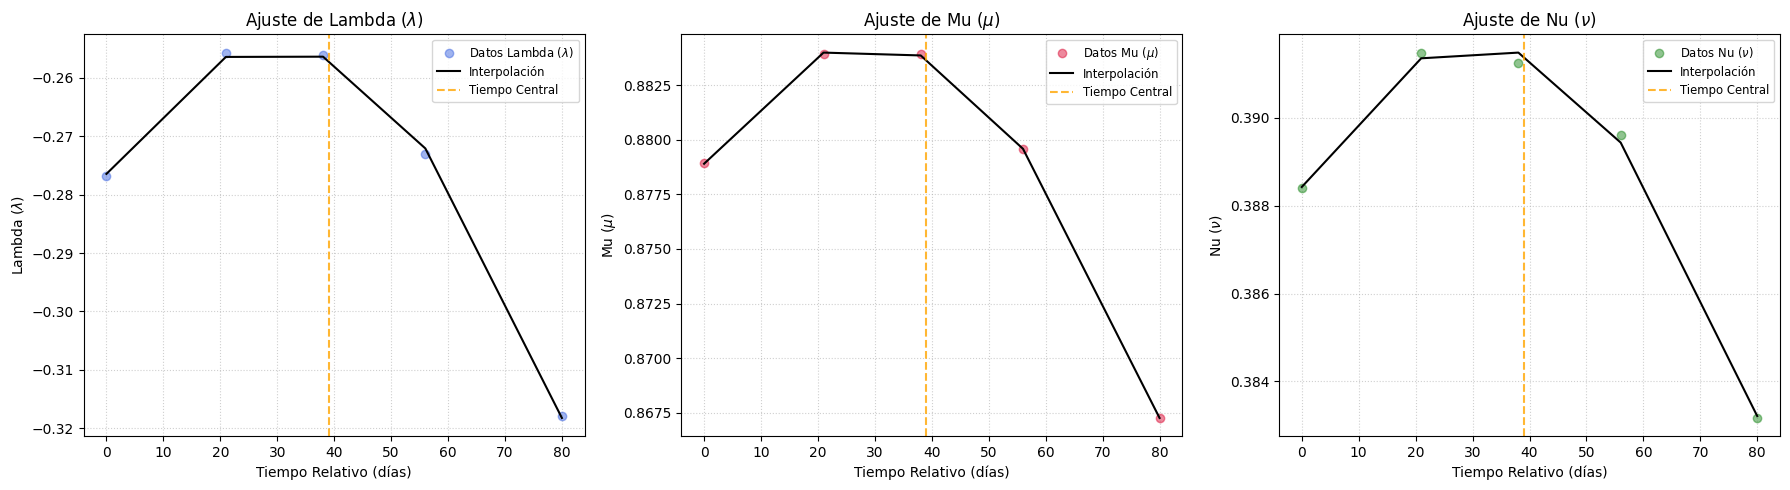

In [313]:
# Definimos las listas de datos para iterar y no repetir código
polinomios_16 = [poly_lambda_16, poly_mu_16, poly_nu_16]
nombres = ['Lambda ($\lambda$)', 'Mu ($\mu$)', 'Nu ($\\nu$)']
colores = ['royalblue', 'crimson', 'forestgreen']

plt.figure(figsize=(18, 5)) # Un ancho mayor para que quepan las tres

for i in range(3):
    plt.subplot(1, 3, i + 1)
    
    # 1. Graficar los datos originales (puntos)
    plt.plot(tiempo_relativo_16, rho_16[:, i], 'o', color=colores[i], 
             alpha=0.5, label=f'Datos {nombres[i]}')
    
    # 2. Graficar la interpolación (línea continua)
    # Suponiendo que tienes poly_lambda, poly_mu y poly_nu ya definidos
    plt.plot(tiempo_relativo_16, np.polyval(polinomios_16[i], tiempo_relativo_16), 
             '-', color='black', linewidth=1.5, label='Interpolación')
    
    # 3. Marcar el tiempo central
    plt.axvline(tiempo_central_reescalado_16, color='orange', linestyle='--', 
                label='Tiempo Central', alpha=0.8)
    
    plt.xlabel('Tiempo Relativo (días)')
    plt.ylabel(nombres[i])
    plt.title(f'Ajuste de {nombres[i]}')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize='small')

    # Importante para ver las variaciones pequeñas (quita el offset)
    plt.gca().ticklabel_format(useOffset=False)
    
plt.tight_layout()
plt.show()

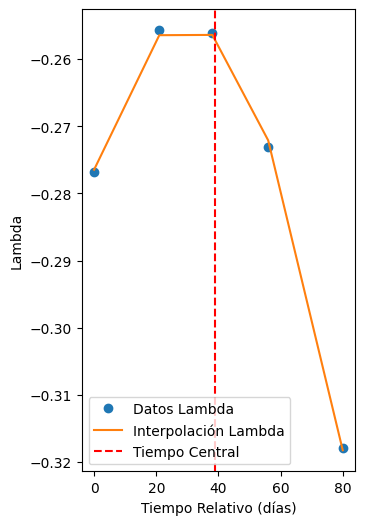

In [222]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_16, rho_16[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_16, np.polyval(poly_lambda_16, tiempo_relativo_16), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_16, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [238]:
X_16 = -9.957637089965080E-01
Y_16 = -4.351313393396847E-02
Z_16 = 5.439964878933487E-06

R_16 = np.sqrt(X_16**2 + Y_16**2 + Z_16**2)
print(R_16)

#23 de marzo

0.996713979539181


In [239]:
#Para lambda

l_val_16 = np.polyval(poly_lambda_16, tiempo_central_reescalado_16)

derivada_1_l_16 = np.polyder(poly_lambda_16,1)
l_dval_16 = np.polyval(derivada_1_l_16, tiempo_central_reescalado_16)

derivada_2_l_16 = np.polyder(poly_lambda_16,2)
l_ddval_16 = np.polyval(derivada_2_l_16, tiempo_central_reescalado_16)

#Para mu

mu_val_16 = np.polyval(poly_mu_16, tiempo_central_reescalado_16)

derivada_1_mu_16 = np.polyder(poly_mu_16,1)
mu_dval_16 = np.polyval(derivada_1_mu_16, tiempo_central_reescalado_16)

derivada_2_mu_16 = np.polyder(poly_mu_16,2)
mu_ddval_16 = np.polyval(derivada_2_mu_16, tiempo_central_reescalado_16)

#Para nu

nu_val_16 = np.polyval(poly_nu_16, tiempo_central_reescalado_16)

derivada_1_nu_16 = np.polyder(poly_nu_16,1)
nu_dval_16 = np.polyval(derivada_1_nu_16, tiempo_central_reescalado_16)

derivada_2_nu_16 = np.polyder(poly_nu_16,2)
nu_ddval_16 = np.polyval(derivada_2_nu_16, tiempo_central_reescalado_16)

In [240]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_16 = np.array([
    [l_val_16,  l_dval_16,  l_ddval_16],
    [mu_val_16, mu_dval_16, mu_ddval_16],
    [nu_val_16, nu_dval_16, nu_ddval_16]
])

# Calcular el determinante D
D_16 = np.linalg.det(matriz_D_16)
print(D_16)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_16 = np.array([
    [l_val_16, l_dval_16, X_16],
    [mu_val_16, mu_dval_16, Y_16],
    [nu_val_16, nu_dval_16, Z_16]
])

#Calcular el determiante D1
D1_16 =- k2* np.linalg.det(matriz_D1_16)
print(D1_16)

#Intento preliminar
intento_16 = D1_16/D_16 * (1/(0.99)**3 - 1/(5.2)**3)
print(intento_16)

-5.226231208873361e-10
-2.472823354756193e-09
4.842744427132489


In [249]:
cos_phi_16 = (l_val_16*X_16 + mu_val_16*Y_16 +nu_val_16*Z_16)/(R_16)

# Bucle para hallar r y rho

r_obj_16 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_16 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_16 = (D1_16 / D_16) * (1/R_16**3 - 1/r_obj_16**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_16 = np.sqrt(rho_new_16**2 + R_16**2 + 2 * rho_new_16 * R_16 * cos_phi_16)
    
    print(f"{i:<5} | {rho_new_16:<15.8f} | {r_obj_16:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_16 - rho_old_16) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_16 = rho_new_16
    i += 1

rho_final_16 = rho_new_16
r_final_16 = r_obj_16

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_16:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_16:.6f} UA")

#El error es de una 0.46 Unidades Astronómicas, lo cual es bastante bueno. Se puede concluir que al usar más datos se obtiene una mejor aproximación. Sin embargo, los datos del 30 de abril siguen teniendo una gran incertidumbre.

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 4.74486287      | 5.05659365     
1     | 4.74191788      | 5.05370369     
2     | 4.74185506      | 5.05364205     
3     | 4.74185372      | 5.05364073     
4     | 4.74185369      | 5.05364070     
5     | 4.74185369      | 5.05364070     
----------------------------------------
¡Convergencia lograda en 5 iteraciones!

Distancia Tierra-Júpiter (rho): 4.741854 UA
Distancia Sol-Júpiter (r): 5.053641 UA


17 Interpolación: 09/02,02/03,26/03,06/04

In [253]:
tiempos_uso_jd_17 = [tiempos_dias_jd[0],tiempos_dias_jd[2],tiempos_dias_jd[5],tiempos_dias_jd[6]]  
print(tiempos_uso_jd_17)

tiempo_central_17 = np.mean(tiempos_uso_jd_17)
print(tiempo_central_17)

#Construcción del vector rho

alpha_17 = [alpha[0],alpha[2],alpha[5],alpha[6]]
delta_17 = [delta[0],delta[2],delta[5],delta[6]]

rho_17 = np.zeros((4, 3))

for i in range(4):
    rho_17[i, 0] = np.cos(delta_17[i]) * np.cos(alpha_17[i])  # x
    rho_17[i, 1] = np.cos(delta_17[i]) * np.sin(alpha_17[i])  # y
    rho_17[i, 2] = np.sin(delta_17[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461102.476388889), np.float64(2461126.504166667), np.float64(2461137.5083333333)]
2461111.9965277775


In [254]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_17 = tiempos_uso_jd_17 - tiempos_uso_jd_17[0]

poly_lambda_17 = np.polyfit(tiempo_relativo_17, rho_17[:, 0], 2)
poly_mu_17 = np.polyfit(tiempo_relativo_17, rho_17[:, 1], 2)
poly_nu_17 = np.polyfit(tiempo_relativo_17, rho_17[:, 2], 2)

tiempo_central_reescalado_17 = tiempo_central_17 - tiempos_uso_jd_17[0] 

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Jessi Dani\AppData\Local\Temp\ipykernel_19052\1112073069.py:3: SyntaxWarning: invalid escape sequence '\l'
  nombres = ['Lambda ($\lambda$)', 'Mu ($\mu$)', 'Nu ($\\nu$)']
C:\Users\Jessi Dani\AppData\Local\Temp\ipykernel_19052\1112073069.py:3: SyntaxWarning: invalid escape sequence '\m'
  nombres = ['Lambda ($\lambda$)', 'Mu ($\mu$)', 'Nu ($\\nu$)']


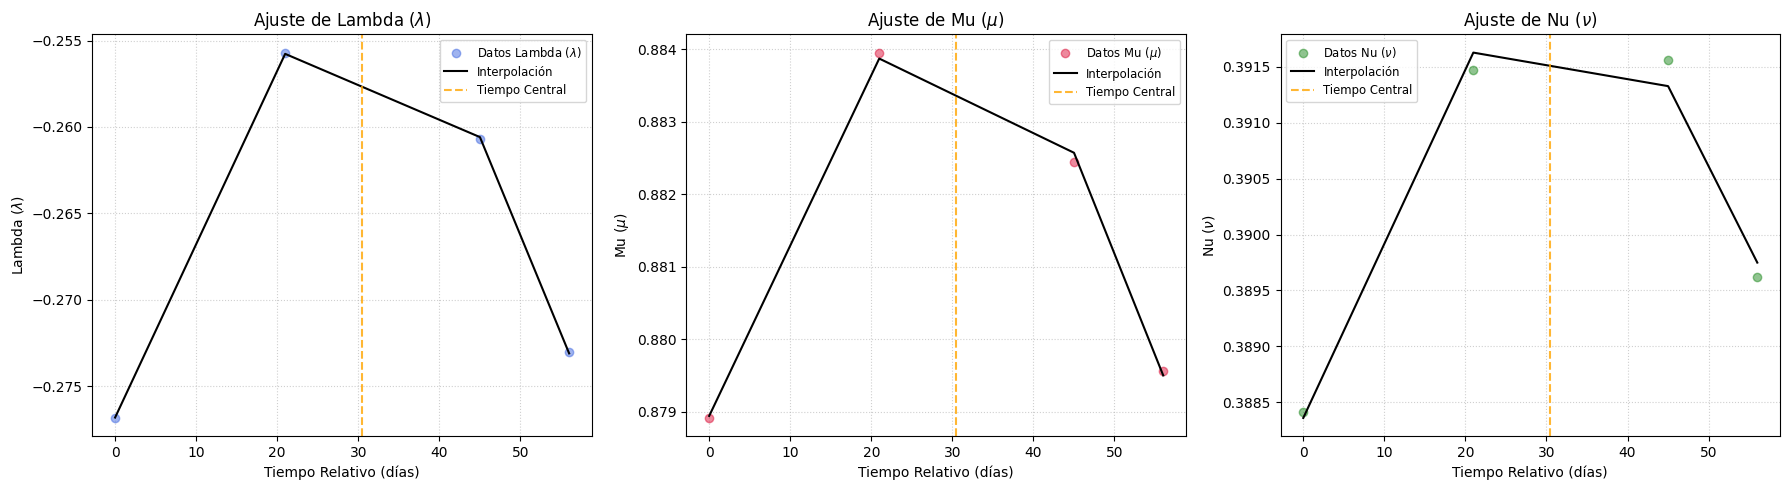

In [314]:
# Definimos las listas de datos para iterar y no repetir código
polinomios_17 = [poly_lambda_17, poly_mu_17, poly_nu_17]
nombres = ['Lambda ($\lambda$)', 'Mu ($\mu$)', 'Nu ($\\nu$)']
colores = ['royalblue', 'crimson', 'forestgreen']

plt.figure(figsize=(18, 5)) # Un ancho mayor para que quepan las tres

for i in range(3):
    plt.subplot(1, 3, i + 1)
    
    # 1. Graficar los datos originales (puntos)
    plt.plot(tiempo_relativo_17, rho_17[:, i], 'o', color=colores[i], 
             alpha=0.5, label=f'Datos {nombres[i]}')
    
    # 2. Graficar la interpolación (línea continua)
    # Suponiendo que tienes poly_lambda, poly_mu y poly_nu ya definidos
    plt.plot(tiempo_relativo_17, np.polyval(polinomios_17[i], tiempo_relativo_17), 
             '-', color='black', linewidth=1.5, label='Interpolación')
    
    # 3. Marcar el tiempo central
    plt.axvline(tiempo_central_reescalado_17, color='orange', linestyle='--', 
                label='Tiempo Central', alpha=0.8)
    
    plt.xlabel('Tiempo Relativo (días)')
    plt.ylabel(nombres[i])
    plt.title(f'Ajuste de {nombres[i]}')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize='small')

    # Importante para ver las variaciones pequeñas (quita el offset)
    plt.gca().ticklabel_format(useOffset=False)
    
plt.tight_layout()
plt.show()

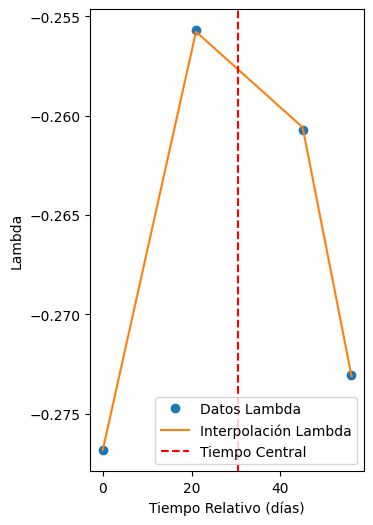

In [255]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_17, rho_17[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_17, np.polyval(poly_lambda_17, tiempo_relativo_17), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_17, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [256]:
X_17 = -9.828898455450190E-01
Y_17 = 1.460123708636412E-01
Z_17 = -5.803376795424789E-07

R_17 = np.sqrt(X_17**2 + Y_17**2 + Z_17**2)
print(R_17)

#12 de marzo

0.9936760341887438


In [257]:
#Para lambda

l_val_17 = np.polyval(poly_lambda_17, tiempo_central_reescalado_17)

derivada_1_l_17 = np.polyder(poly_lambda_17,1)
l_dval_17 = np.polyval(derivada_1_l_17, tiempo_central_reescalado_17)

derivada_2_l_17 = np.polyder(poly_lambda_17,2)
l_ddval_17 = np.polyval(derivada_2_l_17, tiempo_central_reescalado_17)

#Para mu

mu_val_17 = np.polyval(poly_mu_17, tiempo_central_reescalado_17)

derivada_1_mu_17 = np.polyder(poly_mu_17,1)
mu_dval_17 = np.polyval(derivada_1_mu_17, tiempo_central_reescalado_17)

derivada_2_mu_17 = np.polyder(poly_mu_17,2)
mu_ddval_17 = np.polyval(derivada_2_mu_17, tiempo_central_reescalado_17)

#Para nu

nu_val_17 = np.polyval(poly_nu_17, tiempo_central_reescalado_17)

derivada_1_nu_17 = np.polyder(poly_nu_17,1)
nu_dval_17 = np.polyval(derivada_1_nu_17, tiempo_central_reescalado_17)

derivada_2_nu_17 = np.polyder(poly_nu_17,2)
nu_ddval_17 = np.polyval(derivada_2_nu_17, tiempo_central_reescalado_17)

In [259]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_17 = np.array([
    [l_val_17,  l_dval_17,  l_ddval_17],
    [mu_val_17, mu_dval_17, mu_ddval_17],
    [nu_val_17, nu_dval_17, nu_ddval_17]
])

# Calcular el determinante D
D_17 = np.linalg.det(matriz_D_17)
print(D_17)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_17 = np.array([
    [l_val_17, l_dval_17, X_17],
    [mu_val_17, mu_dval_17, Y_17],
    [nu_val_17, nu_dval_17, Z_17]
])

#Calcular el determiante D1
D1_17 = k2* np.linalg.det(matriz_D1_17)
print(D1_17)

#Intento preliminar
intento_17 = D1_17/D_17 * (1/(0.99)**3 - 1/(5.2)**3)
print(intento_17)

-9.206459387722287e-10
-5.164889155277188e-09
5.741897546281753


In [260]:
cos_phi_17 = (l_val_17*X_17 + mu_val_17*Y_17 +nu_val_17*Z_17)/(R_17)

# Bucle para hallar r y rho

r_obj_17 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_17 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_17 = (D1_17 / D_17) * (1/R_17**3 - 1/r_obj_17**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_17 = np.sqrt(rho_new_17**2 + R_17**2 + 2 * rho_new_17 * R_17 * cos_phi_17)
    
    print(f"{i:<5} | {rho_new_17:<15.8f} | {r_obj_17:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_17 - rho_old_17) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_17 = rho_new_17
    i += 1

rho_final_17 = rho_new_17
r_final_17 = r_obj_17

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_17:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_17:.6f} UA")


Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 5.67796660      | 6.12598963     
1     | 5.69346247      | 6.14131071     
2     | 5.69364465      | 6.14149084     
3     | 5.69364678      | 6.14149295     
4     | 5.69364680      | 6.14149297     
5     | 5.69364680      | 6.14149297     
----------------------------------------
¡Convergencia lograda en 5 iteraciones!

Distancia Tierra-Júpiter (rho): 5.693647 UA
Distancia Sol-Júpiter (r): 6.141493 UA


18 Interpolación: 09/02, 02/03,26/03, 30/04

In [261]:
tiempos_uso_jd_18 = [tiempos_dias_jd[0],tiempos_dias_jd[2],tiempos_dias_jd[5],tiempos_dias_jd[7]]  
print(tiempos_uso_jd_18)

tiempo_central_18 = np.mean(tiempos_uso_jd_18)
print(tiempo_central_18)

#Construcción del vector rho

alpha_18 = [alpha[0],alpha[2],alpha[5],alpha[7]]
delta_18 = [delta[0],delta[2],delta[5],delta[7]]

rho_18 = np.zeros((4, 3))

for i in range(4):
    rho_18[i, 0] = np.cos(delta_18[i]) * np.cos(alpha_18[i])  # x
    rho_18[i, 1] = np.cos(delta_18[i]) * np.sin(alpha_18[i])  # y
    rho_18[i, 2] = np.sin(delta_18[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461102.476388889), np.float64(2461126.504166667), np.float64(2461161.4909722223)]
2461117.9921875


In [262]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_18 = tiempos_uso_jd_18 - tiempos_uso_jd_18[0]

poly_lambda_18 = np.polyfit(tiempo_relativo_18, rho_18[:, 0], 2)
poly_mu_18 = np.polyfit(tiempo_relativo_18, rho_18[:, 1], 2)
poly_nu_18 = np.polyfit(tiempo_relativo_18, rho_18[:, 2], 2)

tiempo_central_reescalado_18 = tiempo_central_18 - tiempos_uso_jd_18[0] 

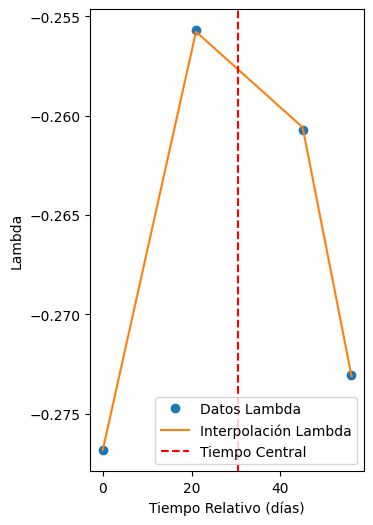

In [263]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_17, rho_17[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_17, np.polyval(poly_lambda_17, tiempo_relativo_17), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_17, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [265]:
X_18 = -9.944025177271714E-01
Y_18 = 4.296130561678477E-02
Z_18 = 2.380529677480794E-06

R_18 = np.sqrt(X_18**2 + Y_18**2 + Z_18**2)
print(R_18)

#18 de marzo

0.9953301166186538


In [266]:
#Para lambda

l_val_18 = np.polyval(poly_lambda_18, tiempo_central_reescalado_18)

derivada_1_l_18 = np.polyder(poly_lambda_18,1)
l_dval_18 = np.polyval(derivada_1_l_18, tiempo_central_reescalado_18)

derivada_2_l_18 = np.polyder(poly_lambda_18,2)
l_ddval_18 = np.polyval(derivada_2_l_18, tiempo_central_reescalado_18)

#Para mu

mu_val_18 = np.polyval(poly_mu_18, tiempo_central_reescalado_18)

derivada_1_mu_18 = np.polyder(poly_mu_18,1)
mu_dval_18 = np.polyval(derivada_1_mu_18, tiempo_central_reescalado_18)

derivada_2_mu_18 = np.polyder(poly_mu_18,2)
mu_ddval_18 = np.polyval(derivada_2_mu_18, tiempo_central_reescalado_18)

#Para nu

nu_val_18 = np.polyval(poly_nu_18, tiempo_central_reescalado_18)

derivada_1_nu_18 = np.polyder(poly_nu_18,1)
nu_dval_18 = np.polyval(derivada_1_nu_18, tiempo_central_reescalado_18)

derivada_2_nu_18 = np.polyder(poly_nu_18,2)
nu_ddval_18 = np.polyval(derivada_2_nu_18, tiempo_central_reescalado_18)

In [267]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_18 = np.array([
    [l_val_18,  l_dval_18,  l_ddval_18],
    [mu_val_18, mu_dval_18, mu_ddval_18],
    [nu_val_18, nu_dval_18, nu_ddval_18]
])

# Calcular el determinante D
D_18 = np.linalg.det(matriz_D_18)
print(D_18)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_18 = np.array([
    [l_val_18, l_dval_18, X_18],
    [mu_val_18, mu_dval_18, Y_18],
    [nu_val_18, nu_dval_18, Z_18]
])

#Calcular el determiante D1
D1_18 = k2* np.linalg.det(matriz_D1_18)
print(D1_18)

#Intento preliminar
intento_18 = D1_18/D_18 * (1/(0.99)**3 - 1/(5.2)**3)
print(intento_18)

-9.48035084562604e-10
-3.6995746261000465e-09
3.9940588306310607


In [268]:
cos_phi_18 = (l_val_18*X_17 + mu_val_18*Y_17 +nu_val_18*Z_17)/(R_17)

# Bucle para hallar r y rho

r_obj_18 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_18 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_18 = (D1_18 / D_18) * (1/R_18**3 - 1/r_obj_18**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_18 = np.sqrt(rho_new_18**2 + R_18**2 + 2 * rho_new_18 * R_18 * cos_phi_18)
    
    print(f"{i:<5} | {rho_new_18:<15.8f} | {r_obj_18:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_18 - rho_old_18) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_18 = rho_new_18
    i += 1

rho_final_18 = rho_new_18
r_final_18 = r_obj_18

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_18:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_18:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 3.92979230      | 4.40761369     
1     | 3.91197181      | 4.39018695     
2     | 3.91142694      | 4.38965417     
3     | 3.91141014      | 4.38963774     
4     | 3.91140963      | 4.38963724     
5     | 3.91140961      | 4.38963722     
6     | 3.91140961      | 4.38963722     
----------------------------------------
¡Convergencia lograda en 6 iteraciones!

Distancia Tierra-Júpiter (rho): 3.911410 UA
Distancia Sol-Júpiter (r): 4.389637 UA


GENERAL

In [123]:
#Construcción del vector rho

rho_g = np.zeros((8, 3))

for i in range(8):
    rho_g[i, 0] = np.cos(delta[i]) * np.cos(alpha[i])  # x
    rho_g[i, 1] = np.cos(delta[i]) * np.sin(alpha[i])  # y
    rho_g[i, 2] = np.sin(delta[i])                     # z

In [124]:
tiempo_uso_jd = tiempos_dias_jd
tiempo_central_g = np.mean(tiempos_dias_jd)
tiempo_central_g

np.float64(2461117.62890625)

In [288]:

#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c: Revisar

tiempo_relativo_g = tiempo_uso_jd - tiempo_uso_jd[0]

poly_lambda_g = np.polyfit(tiempo_relativo_g, rho_g[:, 0], 3)
poly_mu_g = np.polyfit(tiempo_relativo_g, rho_g[:, 1], 3)
poly_nu_g = np.polyfit(tiempo_relativo_g, rho_g[:, 2], 3)

tiempo_central_reescalado_g = tiempo_central_g - tiempo_uso_jd[0] 


<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Jessi Dani\AppData\Local\Temp\ipykernel_19052\886690172.py:3: SyntaxWarning: invalid escape sequence '\l'
  nombres = ['Lambda ($\lambda$)', 'Mu ($\mu$)', 'Nu ($\\nu$)']
C:\Users\Jessi Dani\AppData\Local\Temp\ipykernel_19052\886690172.py:3: SyntaxWarning: invalid escape sequence '\m'
  nombres = ['Lambda ($\lambda$)', 'Mu ($\mu$)', 'Nu ($\\nu$)']


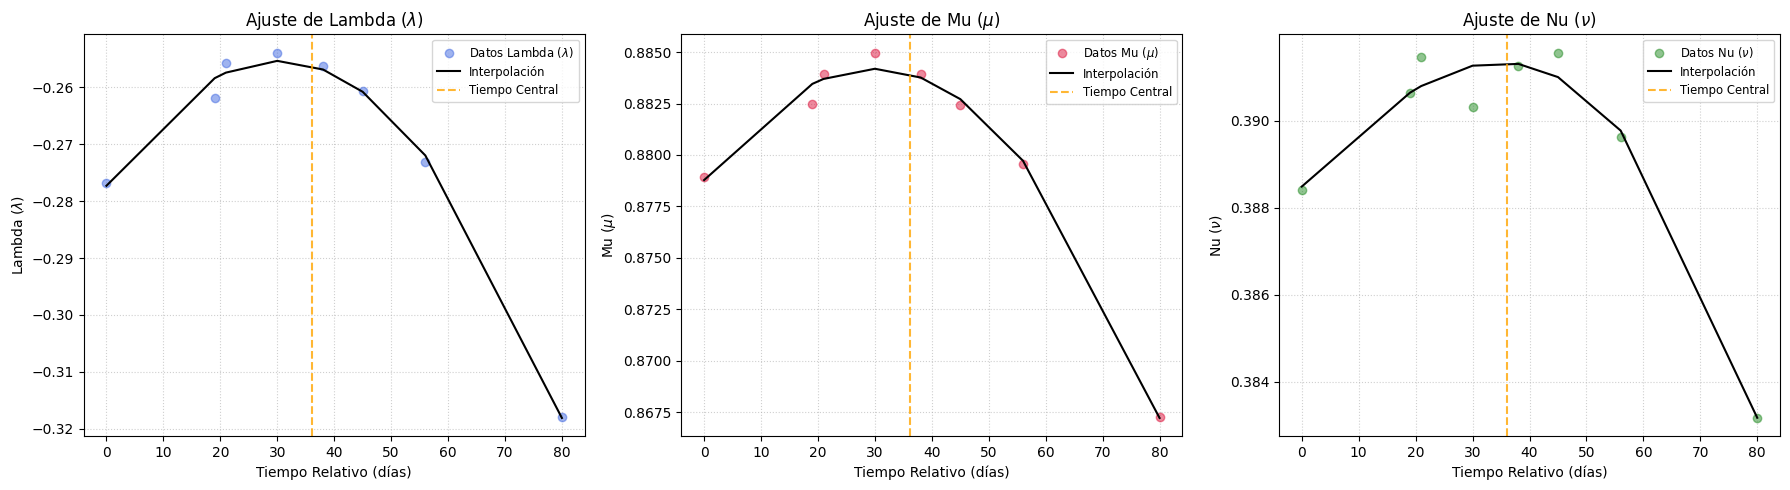

In [315]:
# Definimos las listas de datos para iterar y no repetir código
polinomios_g = [poly_lambda_g, poly_mu_g, poly_nu_g]
nombres = ['Lambda ($\lambda$)', 'Mu ($\mu$)', 'Nu ($\\nu$)']
colores = ['royalblue', 'crimson', 'forestgreen']

plt.figure(figsize=(18, 5)) # Un ancho mayor para que quepan las tres

for i in range(3):
    plt.subplot(1, 3, i + 1)
    
    # 1. Graficar los datos originales (puntos)
    plt.plot(tiempo_relativo_g, rho_g[:, i], 'o', color=colores[i], 
             alpha=0.5, label=f'Datos {nombres[i]}')
    
    # 2. Graficar la interpolación (línea continua)
    # Suponiendo que tienes poly_lambda, poly_mu y poly_nu ya definidos
    plt.plot(tiempo_relativo_g, np.polyval(polinomios_g[i], tiempo_relativo_g), 
             '-', color='black', linewidth=1.5, label='Interpolación')
    
    # 3. Marcar el tiempo central
    plt.axvline(tiempo_central_reescalado_g, color='orange', linestyle='--', 
                label='Tiempo Central', alpha=0.8)
    
    plt.xlabel('Tiempo Relativo (días)')
    plt.ylabel(nombres[i])
    plt.title(f'Ajuste de {nombres[i]}')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize='small')

    # Importante para ver las variaciones pequeñas (quita el offset)
    plt.gca().ticklabel_format(useOffset=False)
    
plt.tight_layout()
plt.show()

In [289]:
np.mean(tiempo_uso_jd)

np.float64(2461117.62890625)

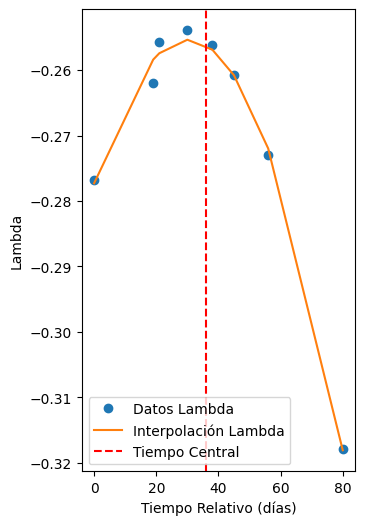

In [290]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_g, rho_g[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_g, np.polyval(poly_lambda_g, tiempo_relativo_g), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_g, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()


In [291]:
#Para lambda

l_val_g = np.polyval(poly_lambda_g, tiempo_central_reescalado_g)

derivada_1_l_g = np.polyder(poly_lambda_g,1)
l_dval_g = np.polyval(derivada_1_l_g, tiempo_central_reescalado_g)

derivada_2_l_g = np.polyder(poly_lambda_g,2)
l_ddval_g = np.polyval(derivada_2_l_g, tiempo_central_reescalado_g)

#Para mu

mu_val_g = np.polyval(poly_mu_g, tiempo_central_reescalado_g)

derivada_1_mu_g = np.polyder(poly_mu_g,1)
mu_dval_g = np.polyval(derivada_1_mu_g, tiempo_central_reescalado_g)

derivada_2_mu_g = np.polyder(poly_mu_g,2)
mu_ddval_g = np.polyval(derivada_2_mu_g, tiempo_central_reescalado_g)

#Para nu

nu_val_g = np.polyval(poly_nu_g, tiempo_central_reescalado_g)

derivada_1_nu_g = np.polyder(poly_nu_g,1)
nu_dval_g = np.polyval(derivada_1_nu_g, tiempo_central_reescalado_g)

derivada_2_nu_g = np.polyder(poly_nu_g,2)
nu_ddval_g = np.polyval(derivada_2_nu_g, tiempo_central_reescalado_g)

In [292]:
X_g = -9.940111185719906E-01
Y_g = 4.923066405959067E-02
Z_g = 2.241584389104348E-06

R_g = np.sqrt(X_g**2 + Y_g**2 + Z_g**2)
R_g

np.float64(0.9952295022423285)

In [293]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_g = np.array([
    [l_val_g,  l_dval_g,  l_ddval_g],
    [mu_val_g, mu_dval_g, mu_ddval_g],
    [nu_val_g, nu_dval_g, nu_ddval_g]
])

# Calcular el determinante D
D_g = np.linalg.det(matriz_D_g)
print(D_g)

#D está dando 1.4240683042675966e-07. O los datos están muys eguidos entre sí, o estamos haciendo algo mal. Revisar.

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_g = np.array([
    [l_val_g, l_dval_g, X_g],
    [mu_val_g, mu_dval_g, Y_g],
    [nu_val_g, nu_dval_g, Z_g]
])

#Calcular el determiante D1
D1_g = k2* np.linalg.det(matriz_D1_g)
print(D1_g)

-1.4705543477908001e-09
-8.957510300512249e-09


In [294]:
#Intento preliminar
intento_g = D1_g/D_g * (1/(0.99)**3 - 1/(5.2)**3)
intento_g

np.float64(6.2343806027679385)

In [295]:
cos_phi_g = (l_val_g*X_g + mu_val_g*Y_g +nu_val_g*Z_g)/(R_g)

# Bucle para hallar r y rho

r_obj_g = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_g = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_g = (D1_g / D_g) * (1/R_g**3 - 1/r_obj_g**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_g = np.sqrt(rho_new_g**2 + R_g**2 + 2 * rho_new_g * R_g * cos_phi_g)
    
    print(f"{i:<5} | {rho_new_g:<15.8f} | {r_obj_g:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_g - rho_old_g) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_g = rho_new_g
    i += 1

rho_final_g = rho_new_g
r_final_g = r_obj_g

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_g:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_g:.6f} UA")

#Existe un error de una Unidad astronómica aproximadamente, lo cual es bastante grande. Esto puede deberse a que los datos están muy seguidos entre sí, o a que el método de interpolación no es el adecuado. (Hay 3 fechhas donde la ascension recta casi no cambia :'c)

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 6.13593984      | 6.50382786     
1     | 6.15711951      | 6.52478135     
2     | 6.15733214      | 6.52499172     
3     | 6.15733426      | 6.52499381     
4     | 6.15733428      | 6.52499383     
5     | 6.15733428      | 6.52499383     
----------------------------------------
¡Convergencia lograda en 5 iteraciones!

Distancia Tierra-Júpiter (rho): 6.157334 UA
Distancia Sol-Júpiter (r): 6.524994 UA


In [140]:
#Finalmente, el vectoor de jupiter es

x_jup_g = X_g + rho_final_g * l_val_g
y_jup_g = Y_g + rho_final_g * mu_val_g
z_jup_g = Z_g + rho_final_g * nu_val_g

vector_r_jupiter_g = np.array([x_jup_g, y_jup_g, z_jup_g])
vector_r_jupiter_g

array([-2.57165374,  5.49195567,  2.40953798])

In [296]:
np.linalg.norm(vector_r_jupiter_g)

np.float64(6.52540062450013)

In [250]:
media_distancias_todas = np.mean([rho_final,rho_final_2,rho_final_3,rho_final_4,rho_final_5,rho_final_6,rho_final_7,rho_final_8,rho_final_9,rho_final_10,
                                  rho_final_11,rho_final_12,rho_final_13,rho_final_14,rho_final_15,rho_final_16,rho_final_g])
print(media_distancias_todas)

media_distancias_solares = np.mean([r_final,r_final_2,r_final_3,r_final_4,r_final_5,r_final_6,r_final_7,r_final_8,r_final_9,r_final_10,
                                   r_final_11,r_final_12,r_final_13,r_final_14,r_final_15,r_final_16,r_final_g])
print(media_distancias_solares)

4.084995595285713
4.637402830041026


Quitando los datos extremos

In [297]:
media_distancias_todas = np.mean([rho_final,rho_final_2,rho_final_4,rho_final_5,rho_final_8,rho_final_10,rho_final_11,
                                  rho_final_13,rho_final_16,rho_final_17,rho_final_18])
print(media_distancias_todas)

media_distancias_solares = np.mean([r_final,r_final_2,r_final_4,r_final_5,r_final_8,r_final_10,r_final_11,
                                    r_final_13,r_final_16,r_final_17,r_final_18])
print(media_distancias_solares)

5.18510845546303
5.676232511796417


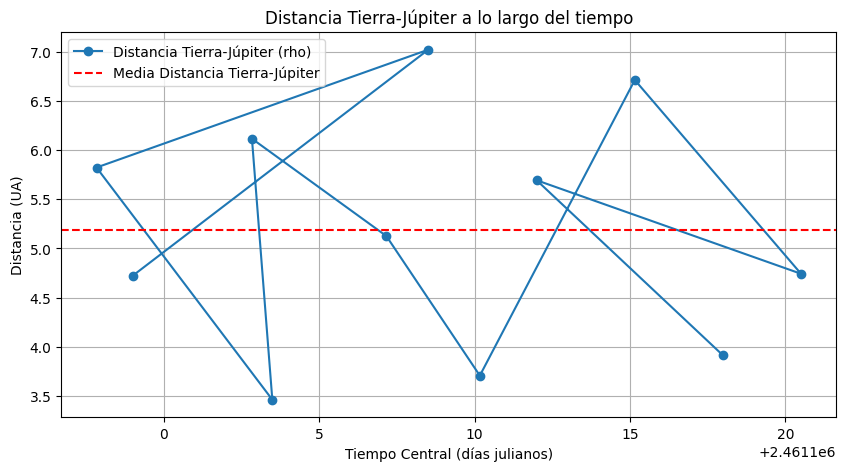

In [298]:
rho_utiles = [rho_final,rho_final_2,rho_final_4,rho_final_5,rho_final_8,rho_final_10,rho_final_11,
               rho_final_13,rho_final_16,rho_final_17,rho_final_18]

tiempo_utiles = [tiempo_central_1,tiempo_central_2,tiempo_central_4,tiempo_central_5,tiempo_central_8,tiempo_central_10,
                 tiempo_central_11,tiempo_central_13,tiempo_central_16,tiempo_central_17,tiempo_central_18]

plt.figure(figsize=(10, 5))
plt.plot(tiempo_utiles, rho_utiles, 'o-', label='Distancia Tierra-Júpiter (rho)')
plt.axhline(media_distancias_todas, color='r', linestyle='--', label='Media Distancia Tierra-Júpiter')
plt.xlabel('Tiempo Central (días julianos)')
plt.ylabel('Distancia (UA)')
plt.title('Distancia Tierra-Júpiter a lo largo del tiempo')
plt.legend()
plt.grid()